#  Исследование результатов А/В-теста и поиск инсайтов

Мобильное приложение для онлайн-торговли финансовыми активами. Целевая аудитория приложения — начинающие инвесторы. Получить доступ к финансовым рынкам можно со смартфона либо через веб-версию. 

Приложение ориентировано на рынок Латинской Америки с акцентом на четыре страны: Мексику, Бразилию, Колумбию и Аргентину, где —  растёт интерес к финтеху и инвестициям. 

Появилась гипотеза о недостаточной финансовой грамотности пользователей: они не понимают, как работать с активами разной степени риска. Клиенты покупают активы с высоким риском и теряют деньги, что снижает вовлечённость.
Команда продукта решила обновить онбординг пользователей и добавить в него детальную информацию о различиях финансовых активов и связанных с ними рисках. Однако появилось опасение, что углублённый онбординг отпугнёт клиентов от пополнения депозита и более рискованных вложений. 

Чтобы разобраться, команда решила провести A/B-эксперимент. 

### А/В-эксперимент

В эксперименте участвовали новые пользователи, которые зарегистрировались в приложении со 2 по 15 июня 2025 года. 
Пользователей случайным образом разделили на две равные группы: 
- Контрольная группа проходила стандартный онбординг без обязательного обучения.
- Тестовая группа проходила обновлённый онбординг с подробной информацией об активах и связанных с ними рисках. 

При внедрении новой фичи команда продукта выдвинула такие гипотезы:
- Гипотеза роста: обучающий онбординг помогает пользователям лучше понимать принципы инвестирования, поэтому они будут чаще открывать второй депозит.
- Гипотеза риска: информация о возможных потерях и высоких рисках отпугнёт некоторых новичков, особенно самых осторожных, что снизит конверсию в первый депозит.
- Дополнительная гипотеза: после нового онбординга пользователи, которые выбрали высокорискованные активы, будут чаще, чем раньше, возвращаться и открывать второй депозит. При старом онбординге пользователи часто покупали активы с высоким риском без понимания последствий. Это приводило к потерям и оттоку после первого депозита. 

Команда выбрала для эксперимента следующий набор метрик: 
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Ожидалось, что ключевая и барьерная метрики не упадут, а вспомогательные покажут значительный рост. 

### Цель проекта:

провести анализ результатов A/B-теста для финансового приложения инвесторов, чтобы оценить влияние обновлённого онбординга на поведение пользователей и их инвестиционную активность.     


#### Задачи: 
#### 1. Анализ исторических данных

- Поведение новых пользователей, в том числе динамику привлечения, сегментацию и ключевые этапы воронки действий.
- Метрики, связанные с внесением депозитов, в том числе средние суммы депозитов. 

#### 2. Анализ данных А/В-теста

- Сравнение поведения пользователей в контрольной и тестовой группах, оценка статистической значимости изменений. 
- Исследование влияния нового онбординга на поведение платящих пользователей с помощью бутстрапа. 



### Данные

 
1. Датасет `/datasets/pa_sollmafin_hist.csv` содержит исторические данные о ключевых действиях новых пользователей, привлечённых в период с 1 апреля по 1 июня 2025 года включительно. 
2. Датасет `/datasets/pa_sollmafin_abt.csv` содержит данные А/В-эксперимента — все действия новых пользователей, которые зарегистрировались со 2 по 15 июня 2025 года включительно. Данные собраны в рамках проверки гипотезы о влиянии нового онбординга на поведение и активность пользователей.

Общие поля датасетов:
- `user_id` — уникальный идентификатор пользователя;
- `country_code` — код страны пользователя в формате ISO (например, `BR` — Бразилия, `MX` — Мексика, `AR` — Аргентина, `CO` — Колумбия);
- `platform` — устройство, с которого пользователь взаимодействует с продуктом: mobile или web;
- `first_ts` — время первого появления пользователя в системе;
- `first_dt` — дата первого появления пользователя (без времени);
- `event_ts` — время события;
- `event_name` — название события;
- `amount` — сумма пополнения депозита;
- `asset` — тип приобретённого актива; 
- `risk_level` — уровень риска актива: low — низкий риск, medium — средний риск, high — высокий риск.

В датасете `/datasets/pa_sollmafin_abt.csv` содержатся два дополнительных поля:
- `ab_test` — название А/В-эксперимента;
- `group` — пользовательская группа А/В-эксперимента.


### План проекта
1. Загрузка исторических данных и их предобработка
2. Исследовательский анализ исторических данных
3. Исследование результатов А/В эксперимента
4. Анализ изменений суммы депозитов на платящего пользователя
5. Выводы

---

## Часть 1

### 1. Загрузка исторических данных и их предобработка

In [1]:
# Загружаем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import math
from scipy import stats
from scipy.stats import ttest_ind
from datetime import datetime, timedelta

from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Загружаем данные и "спарсить" даты, которые известны по описанию данных
hist_df = pd.read_csv('https://code.s3.yandex.net/datasets/pa_sollmafin_hist.csv',  parse_dates=['first_ts','first_dt', 'event_ts'])

In [3]:
# Выведем информацию о датафрейме
hist_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238059 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       238059 non-null  object        
 1   country_code  238059 non-null  object        
 2   platform      238059 non-null  object        
 3   first_ts      238059 non-null  datetime64[ns]
 4   first_dt      238059 non-null  datetime64[ns]
 5   event_ts      238059 non-null  datetime64[ns]
 6   event_name    238059 non-null  object        
 7   amount        33093 non-null   float64       
 8   asset         15392 non-null   object        
 9   risk_level    15392 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 18.2+ MB


In [4]:
# Посмотрим на первые 10 строк
hist_df.head(10)

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN
5,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-04 11:38:02,first_deposit,104.0,NaN,NaN
6,89923614-c303-414d-9788-b5ed77ccc740,BR,mobile,2025-05-12 12:35:02,2025-05-12,2025-05-12 12:35:02,install / open_web,NaN,NaN,NaN
7,89923614-c303-414d-9788-b5ed77ccc740,BR,mobile,2025-05-12 12:35:02,2025-05-12,2025-05-12 12:35:03,introduction,NaN,NaN,NaN
8,89923614-c303-414d-9788-b5ed77ccc740,BR,mobile,2025-05-12 12:35:02,2025-05-12,2025-05-12 21:57:37,registration,NaN,NaN,NaN
9,89923614-c303-414d-9788-b5ed77ccc740,BR,mobile,2025-05-12 12:35:02,2025-05-12,2025-05-12 21:57:40,main_page,NaN,NaN,NaN


In [5]:
# Найдем процент пропущенных значений
round(hist_df.isna().sum()/len(hist_df)*100, 2)

user_id          0.00
country_code     0.00
platform         0.00
first_ts         0.00
first_dt         0.00
event_ts         0.00
event_name       0.00
amount          86.10
asset           93.53
risk_level      93.53
dtype: float64

In [6]:
# Выводим полные дубликаты 
hist_df.duplicated().sum()

0

In [7]:
# Проверим уникальные значения 
# Список столбцов, которые нужно проверить
columns_to_check = ['country_code', 'platform', 'event_name', 'asset', 'risk_level']

# Проходим по каждому столбцу и выводим уникальные значения
for column in columns_to_check:
    unique_values = hist_df[column].sort_values().unique()
    print(f"Уникальные значения в столбце {column}: {unique_values}")

Уникальные значения в столбце country_code: ['AR' 'BR' 'CO' 'MX']
Уникальные значения в столбце platform: ['mobile' 'web']
Уникальные значения в столбце event_name: ['asset_purchase' 'first_deposit' 'install / open_web' 'introduction'
 'main_page' 'onboarding_complete' 'registration' 'second_deposit']
Уникальные значения в столбце asset: ['crypto' 'option' 'stock' nan]
Уникальные значения в столбце risk_level: ['high' 'low' 'medium' nan]


In [8]:
# Прорверим на описательную статистику 
hist_df.describe()

,amount
count,33093.000000
mean,113.527967
std,34.472458
min,27.000000
25%,90.000000
50%,109.000000
75%,131.000000
max,524.000000


In [9]:
# Проверим диапазон дат, минимальный и максимальный интервал для first_ts
min_first_ts = hist_df['first_ts'].min()
max_first_ts = hist_df['first_ts'].max()
print(f"Диапазон дат для first_ts: {min_first_ts} - {max_first_ts}")

Диапазон дат для first_ts: 2025-04-01 00:06:34 - 2025-06-01 23:59:52


In [10]:
# Проверим диапазон дат, минимальный и максимальный интервал для first_dt
min_first_dt = hist_df['first_dt'].min()
max_first_dt = hist_df['first_dt'].max()
print(f"Диапазон дат для first_dt: {min_first_dt} - {max_first_dt}")

Диапазон дат для first_dt: 2025-04-01 00:00:00 - 2025-06-01 00:00:00


In [11]:
# Проверим диапазон дат, минимальный и максимальный интервал для event_ts - время события
min_event_ts = hist_df['event_ts'].min()
max_event_ts = hist_df['event_ts'].max()
print(f"Диапазон дат для event_ts: {min_event_ts} - {max_event_ts}")

Диапазон дат для event_ts: 2025-04-01 00:06:34 - 2025-06-09 20:24:42


**Выводы**: датафрейм имеет 10 столбцов и 238059 строк. Дубликатов нет. Пропуски встречаются в столбцах - amount (86.10%), asset (93.53%), risk_level (93.53%).

Период наблюдения пользователей начинается с первого апреля и заканчивается началом июня 2025 года. Также дата события "event_ts" заканчивается 9 июня, это значит, что люди постепенно проходят все этапы "событий". Стандартное отклонение и медина по описательной статистике отличаются от среднего, скорее всего есть выбросы.

---

### 2. Исследовательский анализ исторических данных
 

**Задача 2.1.** Анализ новых пользователей.


In [12]:
# Группируем по дате и считаем количество уникальных пользователей
new_users_hist = hist_df.groupby('first_dt')['user_id'].nunique().reset_index()
new_users_hist = new_users_hist.rename(columns={'user_id': 'new_users_count'})

In [13]:
# Рассчитываем скользящее среднее количество новых пользователей за 7 дней
new_users_hist['7day_rolling_avg'] = new_users_hist['new_users_count'].rolling(7).mean()
display(new_users_hist)

,first_dt,new_users_count,7day_rolling_avg
0,2025-04-01,670,NaN
1,2025-04-02,676,NaN
2,2025-04-03,691,NaN
3,2025-04-04,637,NaN
4,2025-04-05,640,NaN
...,...,...,...
57,2025-05-28,648,662.142857
58,2025-05-29,673,664.571429
59,2025-05-30,622,655.571429
60,2025-05-31,640,649.285714


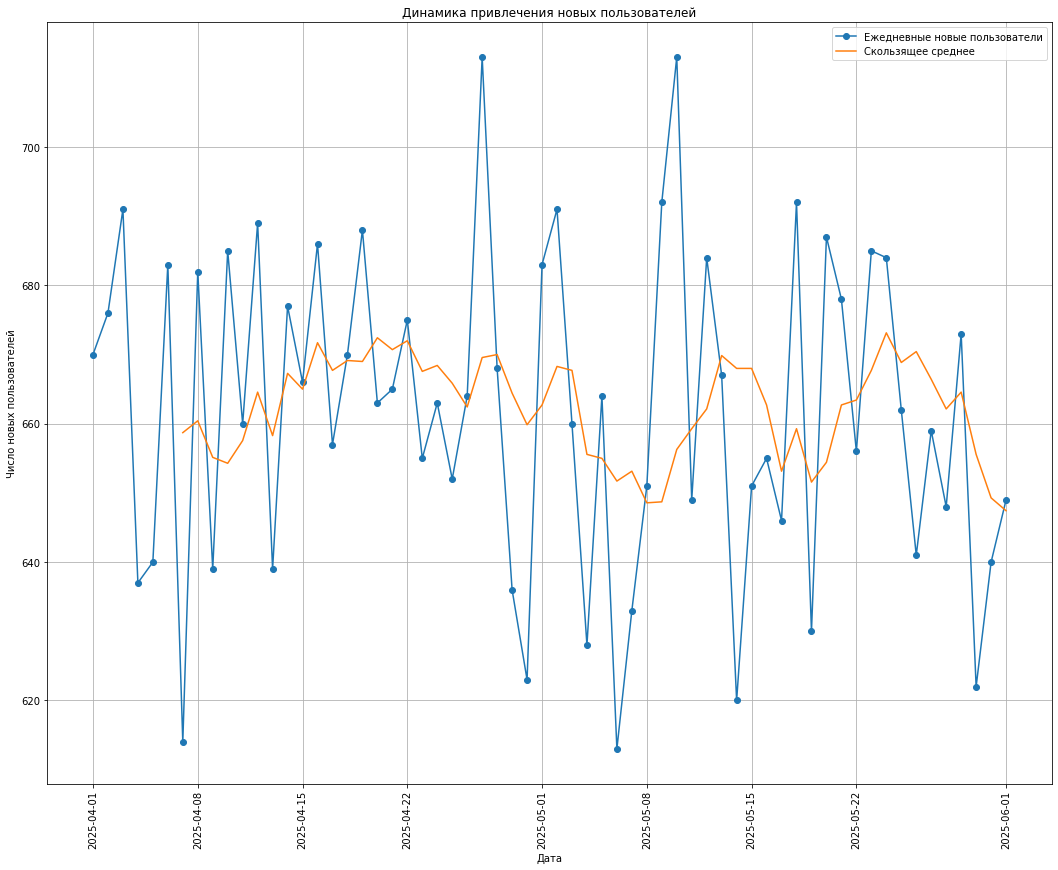

In [14]:
# Строим график
plt.figure(figsize=(18, 14))

plt.plot(new_users_hist['first_dt'], new_users_hist['new_users_count'], marker='o', label='Ежедневные новые пользователи')
plt.plot(new_users_hist['first_dt'], new_users_hist['7day_rolling_avg'], label='Скользящее среднее')

plt.title('Динамика привлечения новых пользователей')
plt.xlabel('Дата')
plt.xticks(rotation=90)
plt.ylabel('Число новых пользователей')
plt.grid(True)
plt.legend()

plt.show()

Вывод: по графику мы видим, что интерес у пользователей к брокерскому приложению на исторических данных сущствует, наблюдается несколько резких подъемов и спадов, которые нивелируют друг друга.
Количество новых пользователей последовательно увеличивается с начала апреля (начало данных: 670) до конца мая (конец данных: 680-730). Благодаря скользящему среднему мы видим, что привлечение стабильно.


In [15]:
# Подсчитаем количество привлеченных пользователей по каждой стране
users_country = hist_df.groupby('country_code')['user_id'].nunique().reset_index()
users_country.sort_values(by='user_id', ascending=False, inplace=True)
display(users_country)

,country_code,user_id
1,BR,12266
3,MX,11303
2,CO,9974
0,AR,7489


Вывод: наибольшее количество представлено пользователей из Бразидии (12266) и наимньшее из Аргентины (7489).

In [16]:
# Группируем по дням и странам, считаем уникальных пользователей
new_users_country = hist_df.groupby(['first_dt', 'country_code'])['user_id'].nunique().reset_index()
new_users_country = new_users_country.rename(columns={'user_id': 'new_users_country'})

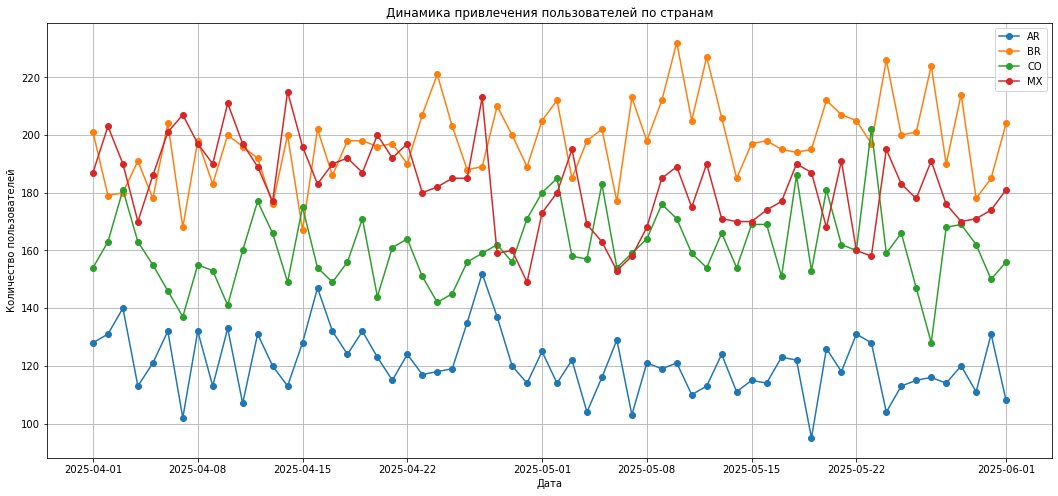

In [17]:
# Визуализация
plt.figure(figsize=(18, 8))

# Проходим по каждой стране и строим график
for country in new_users_country['country_code'].unique():
    df_plot = new_users_country[new_users_country['country_code'] == country]
    plt.plot(df_plot['first_dt'], df_plot['new_users_country'], marker='o', label=country)

plt.title('Динамика привлечения пользователей по странам')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid()
plt.show()


Вывод: Динамика по странам показывает, что в Бразилии (оранжевый цвет) наиболее количество приросших пользователей. В Мексике (красная линия) произошел существенный рост в налале апреля, но далее прирост пользователь снижается. В Колумбии прирост прользователей произошел несущественный. И наименьший рост демонстрирует Аргентина.

In [18]:
# Подсчитаем количество привлеченных пользователей по устройству
users_platform = hist_df.groupby('platform')['user_id'].nunique().reset_index()
users_platform.sort_values(by='user_id', ascending=False, inplace=True)
display(users_platform)

,platform,user_id
0,mobile,28758
1,web,12274


Вывод: наибольший прирост отмечается благодаря мобильному брокерскому приложению.

In [19]:
# Группируем по дням и платформам, считаем уникальных пользователей
new_users_platform = hist_df.groupby(['first_dt', 'platform'])['user_id'].nunique().reset_index()
new_users_platform = new_users_platform.rename(columns={'user_id': 'new_users_platform'})

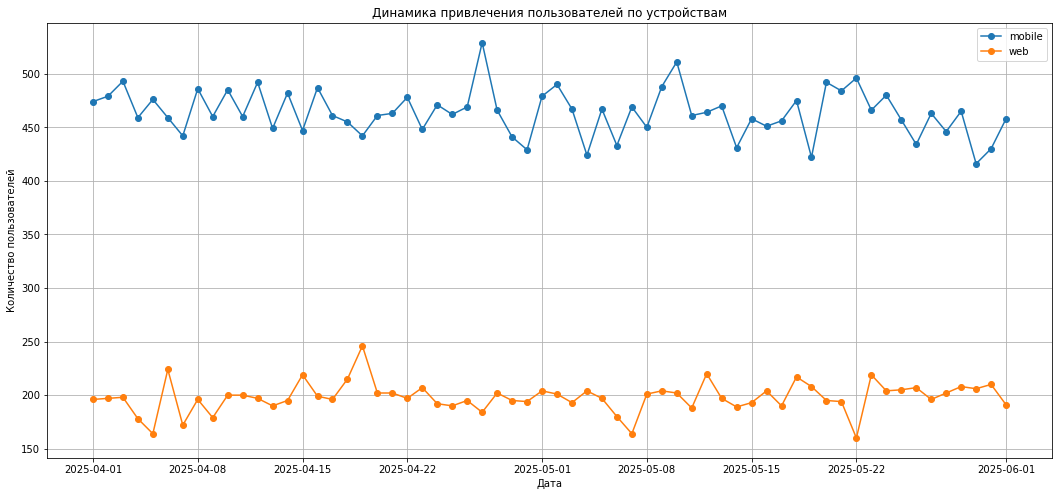

In [20]:
# Визуализация
plt.figure(figsize=(18, 8))

# Проходим по каждой стране и строим график
for platform in new_users_platform['platform'].unique():
    df_plot = new_users_platform[new_users_platform['platform'] == platform]
    plt.plot(df_plot['first_dt'], df_plot['new_users_platform'], marker='o', label=platform)

plt.title('Динамика привлечения пользователей по устройствам')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid()
plt.show()

Вывод: по историческим даным видим, что число новых пользователей по дням, которые приходят через мобильное приложение в 2 раза больше, чем пользователей с сайта.

**Задача 2.2.** Анализ воронок событий.

Пропишем путь пользователя: 
- install / open_web — установка приложения/открытие web страницы
- introduction — знакомство с продуктом
- registration — регистрация
- main_page — личная страница
- onboarding_complete — настройка личной страницы
- first_deposit — внесение первого депозита
- asset_purchase — сделка
- second_deposit - внесение второго депозита

In [21]:
# Задаем порядок шагов в воронке
funnel_steps = ['install / open_web', 'introduction', 'registration', 'main_page', 'onboarding_complete', 'first_deposit', 'asset_purchase', 'second_deposit']

In [22]:
# Фильтруем датасет оставляя только нужные шаги воронки
funnel_df_steps = hist_df[hist_df['event_name'].isin(funnel_steps)]
# Считаем число уникальных пользователей на каждом шаге
funnel_counts = funnel_df_steps.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
print(funnel_counts.head(10))

event_name
install / open_web     41032
introduction           41032
registration           38133
main_page              35040
onboarding_complete    34337
first_deposit          27685
asset_purchase         15392
second_deposit          5408
Name: user_id, dtype: int64


In [23]:
# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step': funnel_steps,
   'users': funnel_counts.values
})

In [24]:
# Добавляем конверсии
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)
display(funnel_df.head(10))

,step,users,conversion_from_first_%,conversion_from_previous_%
0,install / open_web,41032,100.0,NaN
1,introduction,41032,100.0,100.0
2,registration,38133,92.9,92.9
3,main_page,35040,85.4,91.9
4,onboarding_complete,34337,83.7,98.0
5,first_deposit,27685,67.5,80.6
6,asset_purchase,15392,37.5,55.6
7,second_deposit,5408,13.2,35.1


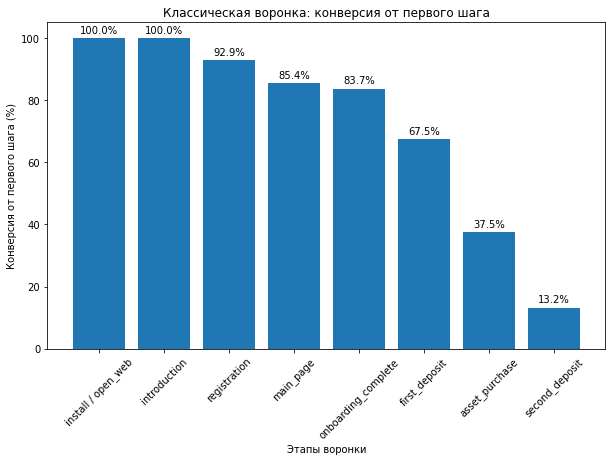

In [25]:
# Визуализируем данные классической воронки
plt.figure(figsize=(10, 6))
# Строим barplot
# Выбор данных для графика
steps = funnel_df['step']
conversions = funnel_df['conversion_from_first_%']

# Построение столбчатой диаграммы
plt.bar(steps, conversions)

plt.title('Классическая воронка: конверсия от первого шага')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки') 
plt.xticks(rotation=45)

# Добавляем числовые значения на столбцы
for i, v in enumerate(conversions):
    plt.text(i, v + 1, str(v) + '%', ha='center', va='bottom')
    
plt.show()

**Вывод**: по классической вопронке мы видим, что "потери" начинают происходит с шага настройка личной страницы (onboarding_complete) до внесения первого депозита (first_deposit) с 83,7% до 67,5%. А далее на шаге покупки (asset_purchase) происходит самая большая потеря в 30% (с 67,5% до 37,5%). До внесения второго депозита (second_deposit) доходит лишь 13,2%, что крайне мало. Таким образом, мы можем выделить, что три основные проблемные зоны:
- asset_purchase (потеря в 30%)
- second_deposit (потеря 24,3%)
- first_deposit (потеря 16,2%)

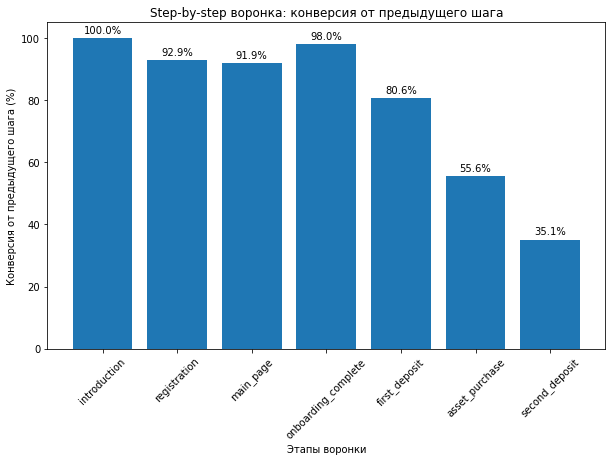

In [26]:
# Визуализируем пошаговую воронку (кроме первого шага, чтобы не выводить NaN)
plt.figure(figsize=(10, 6))
# Строим barplot
# Выбор данных для графика
steps = funnel_df['step'][1:]  # Исключаем первый шаг
conversions = funnel_df['conversion_from_previous_%'][1:]

# Построение столбчатой диаграммы
plt.bar(steps, conversions)

plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)

# Добавляем числовые значения на столбцы
for i, v in enumerate(conversions):
    plt.text(i, v + 1, str(v) + '%', ha='center', va='bottom')    
    
plt.show()

Вывод: аналогичную картину мы видим и на воронке "Step-by-step", наибольшие "потери" фиксируются на шаге:
- asset_purchase (на 25%)
- second_deposit (на 20,5%)
- first_deposit (на 17,4%)

**Задача 2.3.** Влияние уровня риска актива на открытие второго депозита (изучим как уровень риска первого актива влияет на конверсию во второй депозит) 

In [27]:
# Фильруем тех, кто совершид сделку и определяем их первый актив для каждого пользователя
first_asset_per_user = hist_df[hist_df['event_name'] == 'asset_purchase'].sort_values('event_ts').groupby('user_id').first().reset_index()

In [28]:
# Формируем датасет - уровень риска и тип актива для первого актива
first_asset_risk = first_asset_per_user[['user_id', 'risk_level', 'asset']]
print(first_asset_risk)

                                    user_id risk_level   asset
0      000230df-cb80-4a99-9eb4-6e7b559cbd0a     medium   stock
1      00031d01-a2cc-4e28-be64-84c652318cf9       high  option
2      00044258-420d-40a2-8cfe-039c6c9deffd     medium  option
3      000734bf-9751-4dcc-b471-5528605ed91e     medium  crypto
4      00099973-e483-4b9c-963f-5dfd14c5b1a2       high  crypto
...                                     ...        ...     ...
15387  ffe4abdd-209f-4647-b4a7-72e82c88f568     medium   stock
15388  ffe611d0-7fec-4bee-901a-c6a159f8dbac       high   stock
15389  ffe9daa4-fc8e-4e04-8462-03d578f23f03     medium   stock
15390  fff36572-341c-4c83-9ef0-c2d1836559eb       high  option
15391  fffa1397-5456-4ce3-b8de-937d44b84768       high  crypto

[15392 rows x 3 columns]


In [29]:
# Выявляем тех, кто совершил второй депозит
users_with_second_deposit = hist_df[hist_df['event_name'] == 'second_deposit']['user_id'].unique()

In [30]:
# Создаем датафрейм для анализа
analysis_df = first_asset_risk.copy()

# Добавляем столбец, который показывает пользователя с первым активом и со вторым депозитом
analysis_df['has_second_deposit'] = analysis_df['user_id'].isin(users_with_second_deposit).astype(int)

In [31]:
# Группируем по уровню риска и считаем количество пользователей
conversion_by_risk = analysis_df.groupby('risk_level').agg(
    total_users=('user_id', 'count'),
    second_deposit_users=('has_second_deposit', 'sum')
).reset_index()

# Считаем конверсию
conversion_by_risk['conversion_rate'] = round((
    conversion_by_risk['second_deposit_users'] / conversion_by_risk['total_users'] * 100), 2)
print(conversion_by_risk)

  risk_level  total_users  second_deposit_users  conversion_rate
0       high         7740                  2040            26.36
1        low         2327                  1080            46.41
2     medium         5325                  2288            42.97


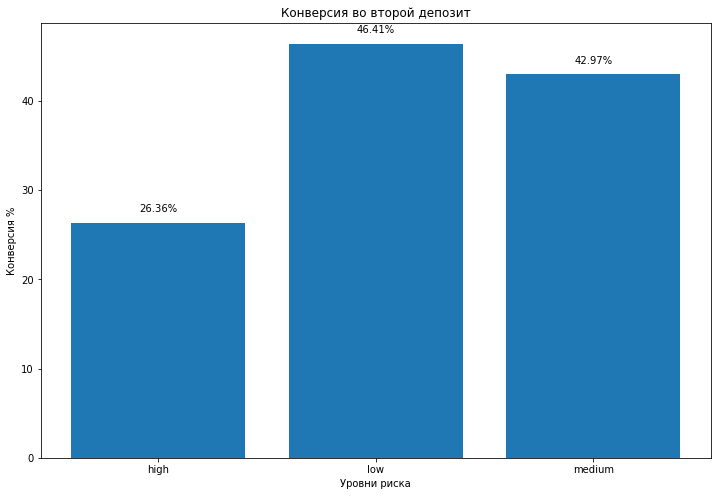

In [32]:
# Визуализируем результаты

plt.figure(figsize=(12, 8))
# Строим barplot
# Выбор данных для графика
risk = conversion_by_risk['risk_level']
conversions = conversion_by_risk['conversion_rate']

# Построение столбчатой диаграммы
plt.bar(risk, conversions)

plt.title('Конверсия во второй депозит')
plt.ylabel('Конверсия %')
plt.xlabel('Уровни риска')   

# Добавляем числовые значения на столбцы
for i, v in enumerate(conversions):
    plt.text(i, v + 1, str(v) + '%', ha='center', va='bottom')
    
plt.show()

**Вывод**: по результатам мы видим, что при низком уровне риска (low) конверсия во второй депозит составляет 46.41%, что выше, чем при среднем (medium) и высоком (high) уровнях риска. Это может означать, что пользователи склонны совершать второй депозит чаще при выборе активов с низким уровнем риска, что говорит об их уверенности в инвестировании.

In [33]:
# Находим количество пользователей по типам актива
asset_users = first_asset_risk.groupby('asset')['user_id'].nunique().reset_index()
print(asset_users)

    asset  user_id
0  crypto     5040
1  option     5189
2   stock     5163


In [34]:
display(hist_df.head())

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN


**Задача 2.4.** Анализ ключевой метрики на исторических данных.
- Рассчитаем ключевую метрику: средняя сумма всех депозитов на одного пользователя (учитываем всех пользователей, которые взаимодействовали с сервисом. Это позволит зафиксировать базовый уровень монетизации).

In [35]:
# Фильтруем данные только по событиям депозитов
deposits_df = hist_df[(hist_df['event_name'] == 'first_deposit') | (hist_df['event_name'] == 'second_deposit')]

In [36]:
deposits_df.head()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
5,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-04 11:38:02,first_deposit,104.0,NaN,NaN
11,89923614-c303-414d-9788-b5ed77ccc740,BR,mobile,2025-05-12 12:35:02,2025-05-12,2025-05-14 21:52:41,first_deposit,130.0,NaN,NaN
18,df7b9aae-7475-4878-a8c7-9bd3002fa226,BR,mobile,2025-04-30 11:19:58,2025-04-30,2025-05-01 01:55:59,first_deposit,88.0,NaN,NaN
25,f18e66dc-e9dd-4608-b067-716ec62f4e70,AR,mobile,2025-04-26 21:42:24,2025-04-26,2025-04-28 05:34:54,first_deposit,106.0,NaN,NaN
32,9445729e-951a-4573-98de-70d9322af290,CO,mobile,2025-04-06 12:17:15,2025-04-06,2025-04-07 06:33:28,first_deposit,131.0,NaN,NaN


In [37]:
# Рассчитываем общую сумму всех депозитов
total_deposits_all = deposits_df['amount'].sum()
print(f"Общая сумма всех депозитов: {total_deposits_all:.2f}")

Общая сумма всех депозитов: 3756981.00


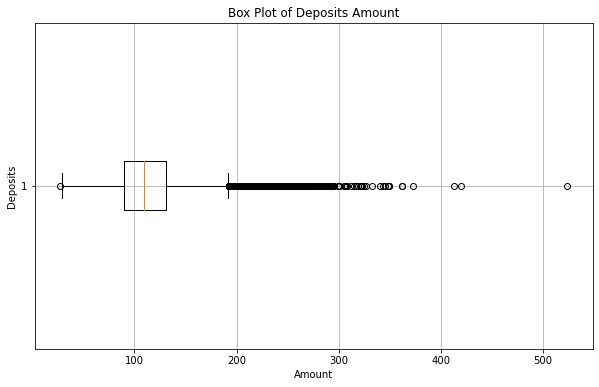

In [38]:
# Смотрим на выбросы
# Создаём box plot для суммы депозитов
plt.figure(figsize=(10, 6))
plt.boxplot(deposits_df['amount'], vert=False, whis=1.5)
plt.title('Box Plot of Deposits Amount')
plt.xlabel('Amount')
plt.ylabel('Deposits')
plt.grid()
plt.show()


Среднее: 113.53
Стандартное отклонение: 34.47


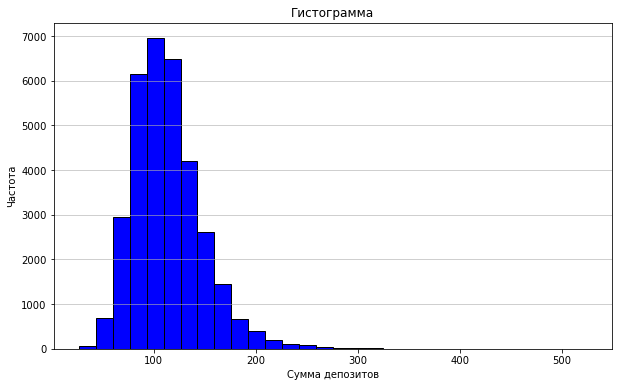

In [39]:
# Считаем среднее и стандартное отклонение
mean = deposits_df['amount'].mean()
std = deposits_df['amount'].std()
median = deposits_df['amount'].median()

print(f"Среднее: {mean:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

# Создаём гистограмму для суммы депозитов
plt.figure(figsize=(10, 6))
plt.hist(deposits_df['amount'], bins=30, color='blue', edgecolor='black')
plt.title('Гистограмма')
plt.xlabel('Сумма депозитов')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.75)
plt.show()

Вывод: по графикам видим, что есть выбросы. Значит, есть пользователи - это крупные ивесторы , кто вносит большие суммы.

Среднее: 112.11
Стандартное отклонение: 31.39


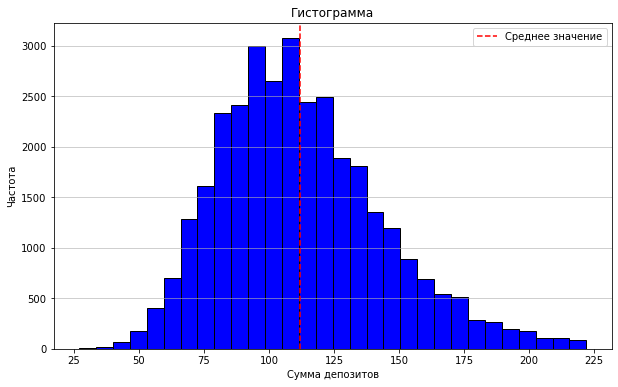

In [40]:
# Определяем 99-й процентиль
percentile = deposits_df['amount'].quantile(0.99)

# Удаляем значения выше 99-го процентиля
filtered_deposits_df = deposits_df[deposits_df['amount'] <= percentile]

# Считаем среднее и стандартное отклонение
mean = filtered_deposits_df['amount'].mean()
std = filtered_deposits_df['amount'].std()

print(f"Среднее: {mean:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

# Создаём гистограмму для суммы депозитов
plt.figure(figsize=(10, 6))
plt.hist(filtered_deposits_df['amount'], bins=30, color='blue', edgecolor='black')
plt.title('Гистограмма')
plt.xlabel('Сумма депозитов')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.75)

# Добавляем вертикальную линию среднего значения
plt.axvline(mean, color='red', linestyle='--', label='Среднее значение')
plt.legend()

plt.show()

In [41]:
# Рассчитываем общую сумму всех депозитов
total_deposits = filtered_deposits_df['amount'].sum()
print(f"Общая сумма всех депозитов: {total_deposits:.2f}")

Общая сумма всех депозитов: 3673139.00


In [42]:
# Рассчитываем всех уникальных пользователей
all_users = hist_df['user_id'].nunique()
print(f"Количество уникальных пользователей: {all_users}")

Количество уникальных пользователей: 41032


In [43]:
# Рассчитываем среднюю сумму депозитов на одного пользователя
avg_deposits = total_deposits / all_users
print(f"Средняя сумма всех депозитов на одного пользователя: {avg_deposits:.2f}")

Средняя сумма всех депозитов на одного пользователя: 89.52


In [44]:
# Рассчитываем среднюю сумму с выбросами
avg_deposits_total = total_deposits_all / all_users
print(f"Средняя сумма всех депозитов на одного пользователя: {avg_deposits_total:.2f}")

Средняя сумма всех депозитов на одного пользователя: 91.56


Вывод: таким образом мы видим, что с выбросами средняя сумма составляет 91,56 , а с определением 99-й процентиля сумма составила 89,52. Следовательно, оставим "китов" - крупных инвесторов. Так как такие явления в банковской сфере частая практика. 

Посмотрим на исторических данных кумулятивную динамику средней суммы в разрезе недель

In [45]:
# Выделяем неделю и сортируем её по неделям
hist_df['week'] = hist_df['first_ts'].dt.to_period('W').dt.to_timestamp()
hist_df = hist_df.sort_values('week')

In [46]:
#Группируем по неделям и рассчитываем общую сумму депозитов
weekly_deposits = hist_df.groupby('week')['amount'].sum().reset_index()

In [47]:
# Группируем по неделям и считаем уникальных пользователей
weekly_new_userss = hist_df.groupby('week')['user_id'].nunique().reset_index()
weekly_new_userss = weekly_new_userss.rename(columns={'user_id': 'new_users_count'})

In [48]:
# Объединяем данные о пользователях и депозитах
weekly_data = pd.merge(weekly_new_userss, weekly_deposits, on='week', how='left')

In [49]:
# Рассчитываем кумулятивные суммы
weekly_data['cumulative_users'] = weekly_data['new_users_count'].cumsum()
weekly_data['cumulative_deposits'] = weekly_data['amount'].cumsum()

In [50]:
# Рассчитываем кумулятивную среднюю сумму депозитов на одного пользователя
weekly_data['average_deposit_per_user'] = weekly_data['cumulative_deposits'] / weekly_data['cumulative_users']

print(weekly_data)

        week  new_users_count    amount  cumulative_users  \
0 2025-03-31             3997  368814.0              3997   
1 2025-04-07             4608  422596.0              8605   
2 2025-04-14             4707  426172.0             13312   
3 2025-04-21             4687  431485.0             17999   
4 2025-04-28             4589  420386.0             22588   
5 2025-05-05             4615  413893.0             27203   
6 2025-05-12             4615  425638.0             31818   
7 2025-05-19             4682  429121.0             36500   
8 2025-05-26             4532  418876.0             41032   

   cumulative_deposits  average_deposit_per_user  
0             368814.0                 92.272705  
1             791410.0                 91.970947  
2            1217582.0                 91.464994  
3            1649067.0                 91.619923  
4            2069453.0                 91.617363  
5            2483346.0                 91.289417  
6            2908984.0          

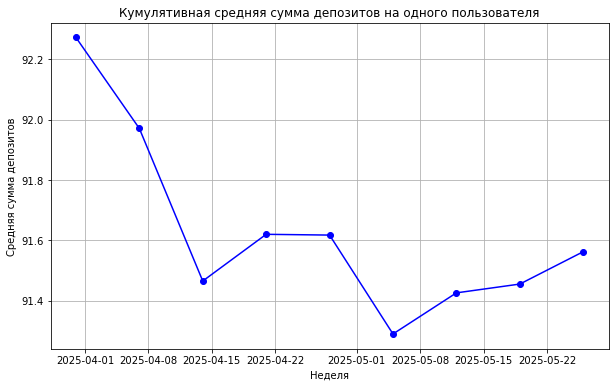

In [51]:
# Создаём график для визуализации кумулятивной средней суммы депозитов на одного пользователя
plt.figure(figsize=(10, 6))
plt.plot(weekly_data['week'], weekly_data['average_deposit_per_user'], marker='o', linestyle='-', color='blue')
plt.title('Кумулятивная средняя сумма депозитов на одного пользователя')
plt.xlabel('Неделя')
plt.ylabel('Средняя сумма депозитов')
plt.grid()
plt.show()

Вывод: по графику мы видим, что на исторических данных средняя сумма депозита снижается, но снижение незначительное.

---

## Часть 2

### 3. Исследование результатов А/В эксперимента
Анализ результатов А/В-эксперимента.

In [52]:
# Загружаем данные и "спарсим" даты, которые известны по описанию данных
ab_df = pd.read_csv('https://code.s3.yandex.net/datasets/pa_sollmafin_abt.csv',  parse_dates=['first_ts','first_dt', 'event_ts'])

In [53]:
# Выведем информацию о датафрейме
ab_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54805 entries, 0 to 54804
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       54805 non-null  object        
 1   country_code  54805 non-null  object        
 2   platform      54805 non-null  object        
 3   first_ts      54805 non-null  datetime64[ns]
 4   first_dt      54805 non-null  datetime64[ns]
 5   event_ts      54805 non-null  datetime64[ns]
 6   event_name    54805 non-null  object        
 7   ab_test       54805 non-null  object        
 8   group         54805 non-null  object        
 9   amount        7843 non-null   float64       
 10  asset         3750 non-null   object        
 11  risk_level    3750 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(8)
memory usage: 5.0+ MB


In [54]:
# Посмотрим на первые 10 строк
ab_df.head(10)

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN
3,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:13,main_page,onboarding_test,test,NaN,NaN,NaN
4,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:33:40,onboarding_complete,onboarding_test,test,NaN,NaN,NaN
5,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-09 05:14:56,first_deposit,onboarding_test,test,83.0,NaN,NaN
6,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-09 11:04:01,asset_purchase,onboarding_test,test,NaN,crypto,high
7,03032063-0f54-444f-a25a-f36448c8b16b,MX,mobile,2025-06-06 12:35:02,2025-06-06,2025-06-06 12:35:02,install / open_web,onboarding_test,test,NaN,NaN,NaN
8,03032063-0f54-444f-a25a-f36448c8b16b,MX,mobile,2025-06-06 12:35:02,2025-06-06,2025-06-06 12:35:04,introduction,onboarding_test,test,NaN,NaN,NaN
9,03032063-0f54-444f-a25a-f36448c8b16b,MX,mobile,2025-06-06 12:35:02,2025-06-06,2025-06-06 15:57:02,registration,onboarding_test,test,NaN,NaN,NaN


In [55]:
# Найдем процент пропущенных значений
round(ab_df.isna().sum()/len(ab_df)*100, 2)

user_id          0.00
country_code     0.00
platform         0.00
first_ts         0.00
first_dt         0.00
event_ts         0.00
event_name       0.00
ab_test          0.00
group            0.00
amount          85.69
asset           93.16
risk_level      93.16
dtype: float64

In [56]:
# Выводим полные дубликаты 
ab_df.duplicated().sum()

0

In [57]:
# Проверим уникальные значения 
# Список столбцов, которые нужно проверить
columns_to_check = ['country_code', 'platform', 'event_name', 'asset', 'risk_level', 'ab_test', 'group']

# Проходим по каждому столбцу и выводим уникальные значения
for column in columns_to_check:
    unique_values = ab_df[column].sort_values().unique()
    print(f"Уникальные значения в столбце {column}: {unique_values}")


Уникальные значения в столбце country_code: ['AR' 'BR' 'CO' 'MX']
Уникальные значения в столбце platform: ['mobile' 'web']
Уникальные значения в столбце event_name: ['asset_purchase' 'first_deposit' 'install / open_web' 'introduction'
 'main_page' 'onboarding_complete' 'registration' 'second_deposit']
Уникальные значения в столбце asset: ['crypto' 'option' 'stock' nan]
Уникальные значения в столбце risk_level: ['high' 'low' 'medium' nan]
Уникальные значения в столбце ab_test: ['onboarding_test']
Уникальные значения в столбце group: ['control' 'test']


In [58]:
# Проверим диапазон дат, минимальный и максимальный интервал для first_dt
min_first_dt = ab_df['first_dt'].min()
max_first_dt = ab_df['first_dt'].max()
print(f"Диапазон дат для first_dt: {min_first_dt} и {max_first_dt}")

Диапазон дат для first_dt: 2025-06-02 00:00:00 и 2025-06-15 00:00:00


In [59]:
# Проверим диапазон дат, минимальный и максимальный интервал для event_ts
min_event_ts = ab_df['event_ts'].min()
max_event_ts = ab_df['event_ts'].max()
print(f"Диапазон дат для event_ts: {min_event_ts} и {max_event_ts}")

Диапазон дат для event_ts: 2025-06-02 00:27:50 и 2025-06-22 13:37:05


In [60]:
# Описательная статистика
display(ab_df['amount'].describe())

count    7843.000000
mean      109.620681
std        86.604702
min        25.000000
25%        62.000000
50%        97.000000
75%       130.500000
max      1050.000000
Name: amount, dtype: float64

Вывод: датафрейм имеет 12 столбцов и 54805 строк. Дубликатов нет. Пропуски встречаются в столбцах - amount (85.69%), asset (93.16%), risk_level (93.16%).

Период наблюдения пользователей начинается cо 2 июня и заканчивается 15 июня 2025 года. А вот дата события "event_ts" заканчивается 22 июня, уже после окончания эксперимента. Стандартное отклонение и медина по описательной статистике отличаются от среднего, скорее всего есть выбросы.

**Задача 3.1.** Анализ аудитории эксперимента. 

In [61]:
# Участники теста
ab_df.groupby(['ab_test', 'group']).agg({'user_id': 'nunique'})

user_id
ab_test         group           
onboarding_test control     4847
                test        4568

In [62]:
# Проверяем группы на пересечения
ab_df.groupby('user_id').agg({'ab_test': 'nunique'}).sort_values(by = 'ab_test', ascending = False).head(5)

,ab_test
user_id,
0004bdca-bbb8-4135-ac72-7b6f5684fa69,1
aac2d656-f81a-4782-891c-1451ceb75bd5,1
aa50786d-4ff6-42e6-820f-fb11788723d2,1
aa739158-af5b-4dcf-9dfe-2adf6dbc5252,1
aa7d6174-e9d1-4d42-945d-ccb47dbe7d0d,1


In [63]:
# Проверяем пользователей для группы А и В на пересечение (вариант 2)
user_test = ab_df[ab_df['group'] == 'test']['user_id']
user_control = ab_df[ab_df['group'] == 'control']['user_id']
intersection = list(set(user_test) & set(user_control))
print(intersection)

[]


In [64]:
# Считаем кол-во уникальных групп на user_id
flawed_users = ab_df.groupby('user_id')['group'].nunique().reset_index()
# Фильтруем клиентов у которых больше 1 группы
flawed_users = flawed_users[flawed_users['group'] > 1]

# Убираем пользователей, попавших в несколько групп
ab_df_correct = ab_df[~ab_df['user_id'].isin(flawed_users['user_id'])]

# выводим текстовое сообщение 'Количество пользователей после очистки: N'
N = ab_df_correct['user_id'].nunique()
print(f'Количество пользователей после очистки: {N}')

Количество пользователей после очистки: 9415


Вывод: группы тестовая и контрольная не пересекаются, в контрольной группе человек больше, чем в тестовой (4847 против 4568)

In [65]:
# Строим распределение пользователей по странам и группам
country_group = ab_df.groupby(['group', 'country_code'])['user_id'].nunique().reset_index()
display(country_group)

,group,country_code,user_id
0,control,AR,756
1,control,BR,1543
2,control,CO,1247
3,control,MX,1301
4,test,AR,725
5,test,BR,1448
6,test,CO,1199
7,test,MX,1196


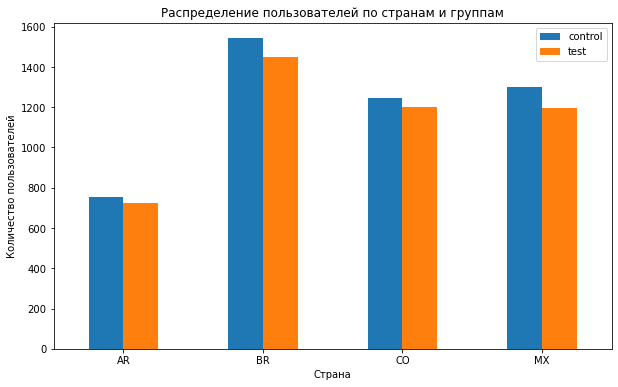

In [66]:
# Создаем сводную таблицу для удобного отображения данных
pivot_table = country_group.pivot(index='country_code', columns='group', values='user_id')


# Строим столбчатую диаграмму
pivot_table.plot(kind='bar', figsize=(10, 6))
plt.title('Распределение пользователей по странам и группам')
plt.xlabel('Страна')
plt.xticks(rotation=0)
plt.ylabel('Количество пользователей')
plt.legend(['control', 'test'])

plt.show() 

Вывод - по каждой стране в контрольной группе чуть больше пользователей, чем в тестовой.

In [67]:
# Строим распределение пользователей по платформе и группам
platform_group = ab_df.groupby(['group', 'platform'])['user_id'].nunique().reset_index()
display(platform_group)

,group,platform,user_id
0,control,mobile,3385
1,control,web,1462
2,test,mobile,3246
3,test,web,1322


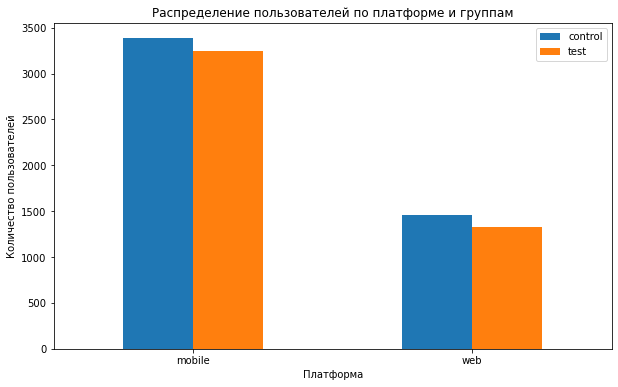

In [68]:
# Создаем сводную таблицу для удобного отображения данных
pivot_table = platform_group.pivot(index='platform', columns='group', values='user_id')

# Строим столбчатую диаграмму
pivot_table.plot(kind='bar', figsize=(10, 6))
plt.title('Распределение пользователей по платформе и группам')
plt.xlabel('Платформа')
plt.xticks(rotation=0)
plt.ylabel('Количество пользователей')
plt.legend(['control', 'test'])
plt.show() 

Вывод - по каждой платформе в контрольной группе чуть больше пользователей, чем в тестовой

**Задача 3.2.** Сравнение воронок событий.

In [69]:
# Задаем порядок шагов в воронке
funnel_steps_ab = ['install / open_web', 'introduction', 'registration', 'main_page', 'onboarding_complete', 'first_deposit', 'asset_purchase', 'second_deposit']

In [70]:
# Фильтруем датасет, оставляя только нужные шаги воронки
funnel_df_steps = ab_df[ab_df['event_name'].isin(funnel_steps_ab)]

# Считаем число уникальных пользователей на каждом шаге в разрезе групп
funnel_counts = funnel_df_steps.groupby(['event_name', 'group'])['user_id'].nunique().unstack(fill_value=0)

print(funnel_counts)


group                control  test
event_name                        
asset_purchase          1773  1977
first_deposit           3228  2987
install / open_web      4847  4568
introduction            4847  4568
main_page               4161  3919
onboarding_complete     4063  3462
registration            4512  4265
second_deposit           654   974


In [71]:
# Переиндексируем по порядку шагов воронки
funnel_counts = funnel_counts.reindex(funnel_steps_ab)

print(funnel_counts)
print("\n")

group                control  test
event_name                        
install / open_web      4847  4568
introduction            4847  4568
registration            4512  4265
main_page               4161  3919
onboarding_complete     4063  3462
first_deposit           3228  2987
asset_purchase          1773  1977
second_deposit           654   974




In [72]:
# Создаем таблицу воронки
funnel_df = pd.DataFrame({
    'step': funnel_steps_ab,
    'control': funnel_counts['control'].values,
    'test': funnel_counts['test'].values})

In [73]:
# Считаем конверсию для тестовой группы
funnel_df['conversion_from_first_%_test'] = (funnel_df['test'] / funnel_df['test'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%_test'] = (funnel_df['test'] / funnel_df['test'].shift(1) * 100).round(1)


display(funnel_df.head(10))

,step,control,test,conversion_from_first_%_test,conversion_from_previous_%_test
0,install / open_web,4847,4568,100.0,NaN
1,introduction,4847,4568,100.0,100.0
2,registration,4512,4265,93.4,93.4
3,main_page,4161,3919,85.8,91.9
4,onboarding_complete,4063,3462,75.8,88.3
5,first_deposit,3228,2987,65.4,86.3
6,asset_purchase,1773,1977,43.3,66.2
7,second_deposit,654,974,21.3,49.3


In [74]:
# Считаем конверсию для контрольной группы
funnel_df['conversion_from_first_%_control'] = (funnel_df['control'] / funnel_df['control'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%_control'] = (funnel_df['control'] / funnel_df['control'].shift(1) * 100).round(1)

display(funnel_df.head(10))

,step,control,test,conversion_from_first_%_test,conversion_from_previous_%_test,conversion_from_first_%_control,conversion_from_previous_%_control
0,install / open_web,4847,4568,100.0,NaN,100.0,NaN
1,introduction,4847,4568,100.0,100.0,100.0,100.0
2,registration,4512,4265,93.4,93.4,93.1,93.1
3,main_page,4161,3919,85.8,91.9,85.8,92.2
4,onboarding_complete,4063,3462,75.8,88.3,83.8,97.6
5,first_deposit,3228,2987,65.4,86.3,66.6,79.4
6,asset_purchase,1773,1977,43.3,66.2,36.6,54.9
7,second_deposit,654,974,21.3,49.3,13.5,36.9


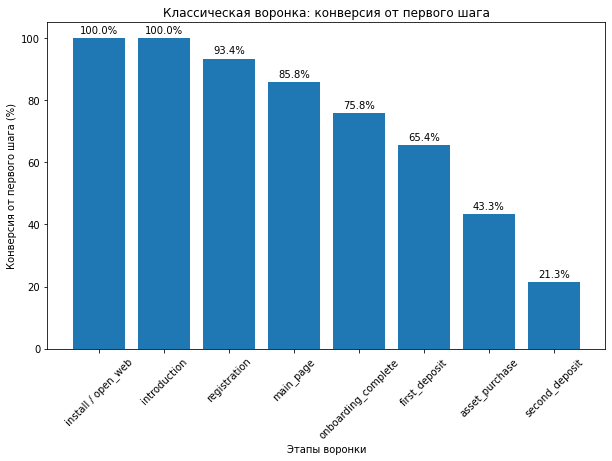

In [75]:
# Визуализируем данные классической воронки "test"
plt.figure(figsize=(10, 6))
# Строим barplot
# Выбор данных для графика
steps = funnel_df['step']
conversions = funnel_df['conversion_from_first_%_test']

# Построение столбчатой диаграммы
plt.bar(steps, conversions)

plt.title('Классическая воронка: конверсия от первого шага')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки') 
plt.xticks(rotation=45)

# Добавляем числовые значения на столбцы
for i, v in enumerate(conversions):
    plt.text(i, v + 1, str(v) + '%', ha='center', va='bottom')
    
plt.show()

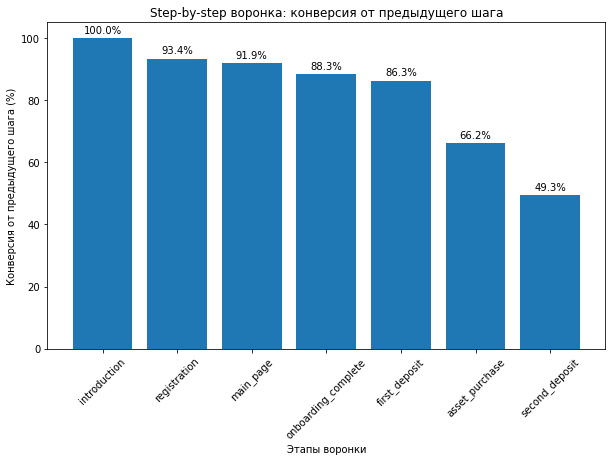

In [76]:
# Визуализируем пошаговую воронку "test"
plt.figure(figsize=(10, 6))
# Строим barplot
# Выбор данных для графика
steps = funnel_df['step'][1:]  # Исключаем первый шаг
conversions = funnel_df['conversion_from_previous_%_test'][1:]

# Построение столбчатой диаграммы
plt.bar(steps, conversions)

plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)

# Добавляем числовые значения на столбцы
for i, v in enumerate(conversions):
    plt.text(i, v + 1, str(v) + '%', ha='center', va='bottom')    
    
plt.show()

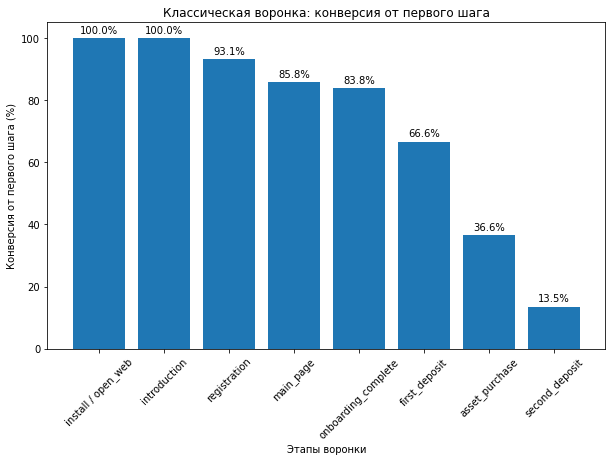

In [77]:
# Визуализируем данные классической воронки "control"
plt.figure(figsize=(10, 6))
# Строим barplot
# Выбор данных для графика
steps = funnel_df['step']
conversions = funnel_df['conversion_from_first_%_control']

# Построение столбчатой диаграммы
plt.bar(steps, conversions)

plt.title('Классическая воронка: конверсия от первого шага')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки') 
plt.xticks(rotation=45)

# Добавляем числовые значения на столбцы
for i, v in enumerate(conversions):
    plt.text(i, v + 1, str(v) + '%', ha='center', va='bottom')
    
plt.show()

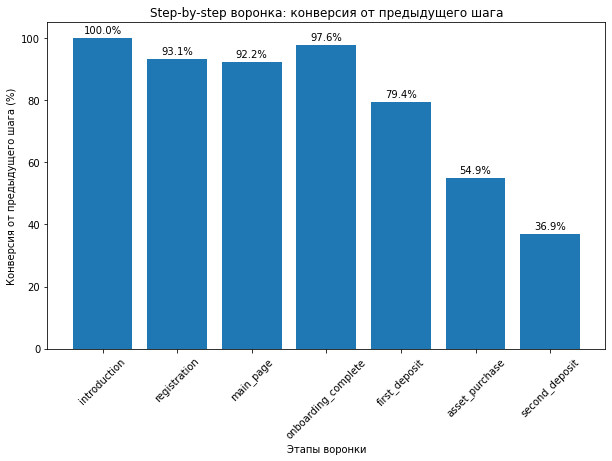

In [78]:
# Визуализируем пошаговую воронку "control"
plt.figure(figsize=(10, 6))
# Строим barplot
# Выбор данных для графика
steps = funnel_df['step'][1:]  # Исключаем первый шаг
conversions = funnel_df['conversion_from_previous_%_control'][1:]

# Построение столбчатой диаграммы
plt.bar(steps, conversions)

plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)

# Добавляем числовые значения на столбцы
for i, v in enumerate(conversions):
    plt.text(i, v + 1, str(v) + '%', ha='center', va='bottom')    
    
plt.show()

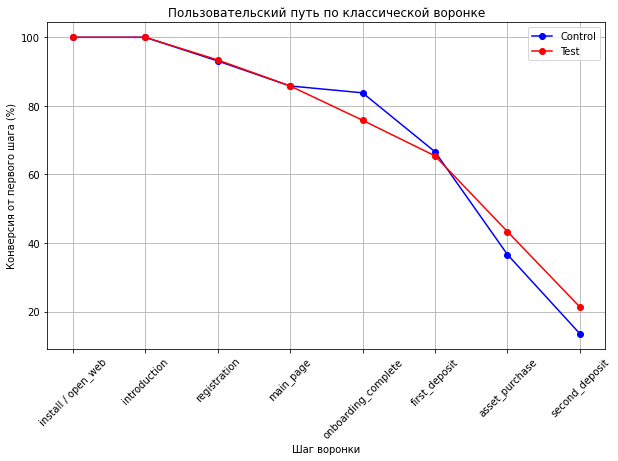

In [79]:
# Сравнительный анализ "control" и "test"
# Создаём график для визуализации пользовательского пути по классической воронке "control" и "test"
plt.figure(figsize=(10, 6))
plt.plot(funnel_df['step'], funnel_df['conversion_from_first_%_control'], marker='o', linestyle='-', color='blue', label='Control')
plt.plot(funnel_df['step'], funnel_df['conversion_from_first_%_test'], marker='o', linestyle='-', color='red', label='Test')
plt.title('Пользовательский путь по классической воронке')
plt.xlabel('Шаг воронки')
plt.ylabel('Конверсия от первого шага (%)')
plt.legend()
plt.grid()
plt.xticks(rotation=45)  # Поворот подписей по оси X для лучшего отображения
plt.show()

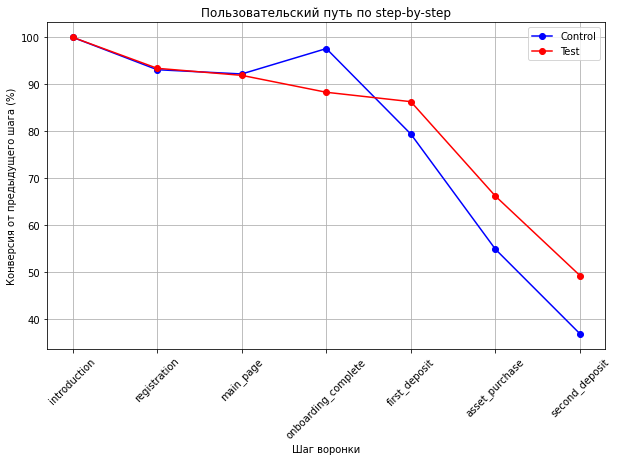

In [80]:
# Сравнительный анализ "control" и "test"
# Создаём график для визуализации пользовательского пути по step-by-step "control" и "test"
plt.figure(figsize=(10, 6))
plt.plot(funnel_df['step'], funnel_df['conversion_from_previous_%_control'], marker='o', linestyle='-', color='blue', label='Control')
plt.plot(funnel_df['step'], funnel_df['conversion_from_previous_%_test'], marker='o', linestyle='-', color='red', label='Test')
plt.title('Пользовательский путь по step-by-step')
plt.xlabel('Шаг воронки')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.legend()
plt.grid()
plt.xticks(rotation=45)  # Поворот подписей по оси X для лучшего отображения
plt.show()

Вывод: тестовая группа показывает лучшие результаты воронки как классической, так и step-by-step. Стоит отметить, что на шаге "onboarding_complete" результат у контрольной группы выше чем у тестовой. Однако с шага "first_deposit" и до шага "second_deposit" показатели лучше у тестовой группы, особенно на воронке от предыдущего шага. 
Мы видим, что после прохождения онбординга часть пользователей отсеивается, что влияет на завершение цепочки. Но те, кто прошёл онбординг, становятся более мотивированными и активнее совершают первый депозит. В результате общая конверсия в первый депозит сохраняется на том же уровне - за счёт более целевых и вовлечённых пользователей, которые с большей вероятностью продолжают движение по воронке.

**Задача 3.3.** Влияние новой фичи на конверсию во второй депозит с учётом уровня риска купленного актива (изучим как категория риска купленного актива влияет на вероятность открытия второго депозита в тестовой и контрольной группах)

In [81]:
# Разделим на два датасета контрольную и тестовую группы
test_group = ab_df[ab_df['group'] == 'test']
control_group = ab_df[ab_df['group'] == 'control']
display(test_group)
display(control_group)

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN
3,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:13,main_page,onboarding_test,test,NaN,NaN,NaN
4,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:33:40,onboarding_complete,onboarding_test,test,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
54785,3668967c-b7be-40c6-b5ae-5a013a60cca8,AR,mobile,2025-06-10 09:05:45,2025-06-10,2025-06-12 02:47:29,second_deposit,onboarding_test,test,650.0,NaN,NaN
54801,e2acce7e-90b1-4c9f-8ce8-1a48953669d8,BR,web,2025-06-15 12:20:51,2025-06-15,2025-06-15 12:20:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
54802,e2acce7e-90b1-4c9f-8ce8-1a48953669d8,BR,web,2025-06-15 12:20:51,2025-06-15,2025-06-15 12:20:52,introduction,onboarding_test,test,NaN,NaN,NaN
54803,e2acce7e-90b1-4c9f-8ce8-1a48953669d8,BR,web,2025-06-15 12:20:51,2025-06-15,2025-06-15 18:46:57,registration,onboarding_test,test,NaN,NaN,NaN


,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
20,db37d8ea-902a-41ea-a0b4-b355167c8f74,BR,web,2025-06-09 21:42:24,2025-06-09,2025-06-09 21:42:24,install / open_web,onboarding_test,control,NaN,NaN,NaN
21,db37d8ea-902a-41ea-a0b4-b355167c8f74,BR,web,2025-06-09 21:42:24,2025-06-09,2025-06-09 21:42:26,introduction,onboarding_test,control,NaN,NaN,NaN
22,db37d8ea-902a-41ea-a0b4-b355167c8f74,BR,web,2025-06-09 21:42:24,2025-06-09,2025-06-10 02:21:24,registration,onboarding_test,control,NaN,NaN,NaN
23,db37d8ea-902a-41ea-a0b4-b355167c8f74,BR,web,2025-06-09 21:42:24,2025-06-09,2025-06-10 02:21:27,main_page,onboarding_test,control,NaN,NaN,NaN
24,db37d8ea-902a-41ea-a0b4-b355167c8f74,BR,web,2025-06-09 21:42:24,2025-06-09,2025-06-10 02:25:42,onboarding_complete,onboarding_test,control,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
54796,e3e7417d-6402-4971-a30d-47aba10de59e,CO,web,2025-06-12 13:03:15,2025-06-12,2025-06-12 14:48:20,main_page,onboarding_test,control,NaN,NaN,NaN
54797,e3e7417d-6402-4971-a30d-47aba10de59e,CO,web,2025-06-12 13:03:15,2025-06-12,2025-06-12 14:52:10,onboarding_complete,onboarding_test,control,NaN,NaN,NaN
54798,e3e7417d-6402-4971-a30d-47aba10de59e,CO,web,2025-06-12 13:03:15,2025-06-12,2025-06-14 01:54:22,first_deposit,onboarding_test,control,63.0,NaN,NaN
54799,e3e7417d-6402-4971-a30d-47aba10de59e,CO,web,2025-06-12 13:03:15,2025-06-12,2025-06-15 11:22:25,asset_purchase,onboarding_test,control,NaN,crypto,medium


In [82]:
# Фильруем тех, кто совершид сделку и определяем их первый актив для каждого пользователя в тестовой группе
first_asset_test = test_group[test_group['event_name'] == 'asset_purchase'].sort_values('event_ts').groupby('user_id').first().reset_index()

In [83]:
# Формируем датасет - уровень риска и тип актива для первого актива тестовой группы
first_asset_risk_test = first_asset_test[['user_id', 'risk_level', 'asset']]
print(first_asset_risk_test)

                                   user_id risk_level   asset
0     0009aedc-c389-4824-a05a-2354883b8c7e        low   stock
1     00191c86-8925-483c-9e4c-0859df770f3a     medium  crypto
2     00a1052c-e742-4aa7-9e8c-f318943836ae        low   stock
3     00af20e6-8235-46bb-960f-f895f918f902       high  option
4     00bdd052-646f-4c53-9b07-5fe62e980001       high  crypto
...                                    ...        ...     ...
1972  ff78a5c1-4df9-4c89-9db9-f2ab6f6651ad       high  crypto
1973  ffbdc619-494e-4f08-93c3-c83bbfb55dc2       high  crypto
1974  ffcd35b3-e39f-45c6-85d5-8d207283dbdd     medium  option
1975  ffecaf77-cfce-4def-a2ef-b6aff0c990d0        low   stock
1976  fff664fd-e4eb-4a43-942d-862b0493b299       high  option

[1977 rows x 3 columns]


In [84]:
# Выявляем тех, кто совершил второй депозит в тестовой группе
users_test_second_deposit = test_group[test_group['event_name'] == 'second_deposit']['user_id'].unique()

In [85]:
# Создаем датафрейм для анализа для тестовой группы
analysis_test_df = first_asset_risk_test.copy()

In [86]:
# Добавляем столбец, который показывает пользователя с первым активом и со вторым депозитом
analysis_test_df['test_second_deposit'] = analysis_test_df['user_id'].isin(users_test_second_deposit).astype(int)

In [87]:
# Группируем по уровню риска и считаем количество пользователей в тестовой группе
conversion_by_risk_test = analysis_test_df.groupby('risk_level').agg(
    total_users=('user_id', 'count'),
    second_deposit_users=('test_second_deposit', 'sum')
).reset_index()

In [88]:
# Считаем конверсию в тестовой группе
conversion_by_risk_test['conversion_rate_test'] = round((
    conversion_by_risk_test['second_deposit_users'] / conversion_by_risk_test['total_users'] * 100), 2)
print(conversion_by_risk_test)

  risk_level  total_users  second_deposit_users  conversion_rate_test
0       high          737                   339                 46.00
1        low          496                   285                 57.46
2     medium          744                   350                 47.04


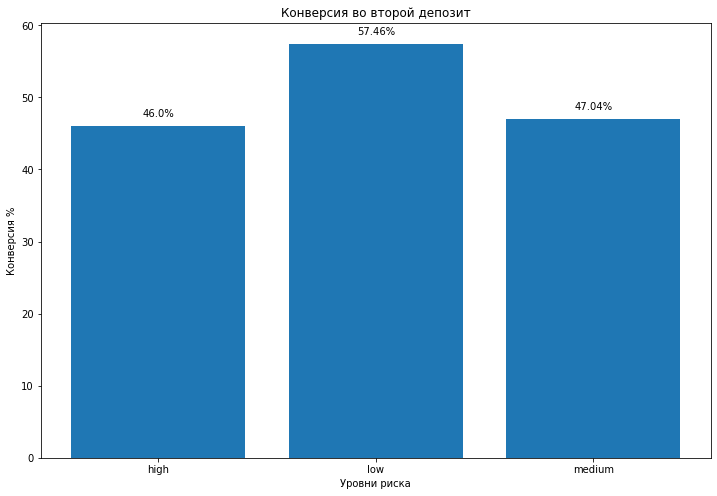

In [89]:
# Визуализируем результаты конверсии в тестовой группе
plt.figure(figsize=(12, 8))
# Строим barplot
# Выбор данных для графика
risk = conversion_by_risk_test['risk_level']
conversions = conversion_by_risk_test['conversion_rate_test']

# Построение столбчатой диаграммы
plt.bar(risk, conversions)

plt.title('Конверсия во второй депозит')
plt.ylabel('Конверсия %')
plt.xlabel('Уровни риска')   

# Добавляем числовые значения на столбцы
for i, v in enumerate(conversions):
    plt.text(i, v + 1, str(v) + '%', ha='center', va='bottom')
    
plt.show()

In [90]:
# Проделываем все тоже самое, но только с контрольной группой
# Фильруем тех, кто совершид сделку и определяем их первый актив для каждого пользователя в контрольной группе
first_asset_control = control_group[control_group['event_name'] == 'asset_purchase'].sort_values('event_ts').groupby('user_id').first().reset_index()

In [91]:
# Формируем датасет - уровень риска и тип актива для первого актива контрольной группы
first_asset_risk_control = first_asset_control[['user_id', 'risk_level', 'asset']]
print(first_asset_risk_control)

                                   user_id risk_level   asset
0     00219f2d-50cc-4ec9-8f5b-6007b0565da0     medium  crypto
1     004951da-06b7-4d53-9df0-7ada3f9179d9       high  option
2     00dc921c-caea-4139-a648-0dde6286b1ed       high  option
3     00f56ea4-e893-45c1-99ce-637016787382     medium   stock
4     0103ab4d-584f-4428-b52f-6b5dd5c58c76       high  option
...                                    ...        ...     ...
1768  ff2f940f-b4cf-46a9-bceb-8a9a7e0779aa       high  option
1769  ff308f02-7878-4e1c-a45a-69f6975a033f       high  crypto
1770  ffe28489-66bc-40cc-84e4-371e356873b5       high  option
1771  fff05a96-6ddd-4d72-8e15-1a98b6030edb       high  option
1772  fff1c9fa-c5a3-4fab-a13d-0211acf6f21e       high  option

[1773 rows x 3 columns]


In [92]:
# Выявляем тех, кто совершил второй депозит в контрольной группе
users_control_second_deposit = control_group[control_group['event_name'] == 'second_deposit']['user_id'].unique()

In [93]:
# Создаем датафрейм для анализа для контрольной группы
analysis_control_df = first_asset_risk_control.copy()

In [94]:
# Добавляем столбец, который показывает пользователя с первым активом и со вторым депозитом
analysis_control_df['control_second_deposit'] = analysis_control_df['user_id'].isin(users_control_second_deposit).astype(int)

In [95]:
# Группируем по уровню риска и считаем количество пользователей в контрольной группе
conversion_by_risk_control = analysis_control_df.groupby('risk_level').agg(
    total_users=('user_id', 'count'),
    second_deposit_users=('control_second_deposit', 'sum')
).reset_index()

In [96]:
# Считаем конверсию в контрольной группе
conversion_by_risk_control['conversion_rate_control'] = round((
    conversion_by_risk_control['second_deposit_users'] / conversion_by_risk_control['total_users'] * 100), 2)
print(conversion_by_risk_control)

  risk_level  total_users  second_deposit_users  conversion_rate_control
0       high          893                   247                    27.66
1        low          285                   142                    49.82
2     medium          595                   265                    44.54


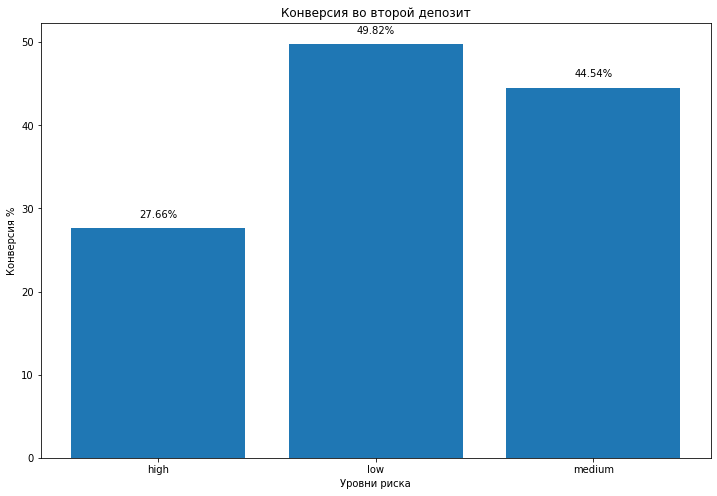

In [97]:
# Визуализируем результаты конверсии в контрольной группе
plt.figure(figsize=(12, 8))
# Строим barplot
# Выбор данных для графика
risk = conversion_by_risk_control['risk_level']
conversions = conversion_by_risk_control['conversion_rate_control']

# Построение столбчатой диаграммы
plt.bar(risk, conversions)

plt.title('Конверсия во второй депозит')
plt.ylabel('Конверсия %')
plt.xlabel('Уровни риска')   

# Добавляем числовые значения на столбцы
for i, v in enumerate(conversions):
    plt.text(i, v + 1, str(v) + '%', ha='center', va='bottom')
    
plt.show()

In [98]:
# Объединяем две таблицы по столбцу risk_level
combined_table = pd.merge(conversion_by_risk_control[['risk_level', 'conversion_rate_control']],
                          conversion_by_risk_test[['risk_level', 'conversion_rate_test']],
                          on='risk_level')

print(combined_table)

  risk_level  conversion_rate_control  conversion_rate_test
0       high                    27.66                 46.00
1        low                    49.82                 57.46
2     medium                    44.54                 47.04


Проверяем статистическую значимую разницу между группами. Для проверки будем использовать Z-тест.

- **Нулевая гипотеза H₀:** Конверсия во второй депозит в рамках одной группы риска для контрольной и тестовой групп не различается

- **Альтернативная гипотеза H₁:** Конверсия во второй депозит в рамках одной группы риска для тестовой группы выше, чем для контрольной (p_control < p_test)

In [99]:
# Подготавливаем данные для Z-теста для каждой группы риска
risk_levels = conversion_by_risk_test['risk_level'].unique()
for risk in risk_levels:
    successes_test = conversion_by_risk_test[conversion_by_risk_test['risk_level'] == risk]['second_deposit_users'].values[0]
    trials_test = conversion_by_risk_test[conversion_by_risk_test['risk_level'] == risk]['total_users'].values[0]
    successes_control = conversion_by_risk_control[conversion_by_risk_control['risk_level'] == risk]['second_deposit_users'].values[0]
    trials_control = conversion_by_risk_control[conversion_by_risk_control['risk_level'] == risk]['total_users'].values[0]

    # Проводим Z-тест для двух пропорций с альтернативой 'smaller' потому что H_1: p_control < p_test
    z_stat, p_value = proportions_ztest([successes_control, successes_test], [trials_control, trials_test], alternative='smaller') 

    # Уровень значимости
    alpha = 0.05

    # Интерпретация результата
    if p_value < alpha:
        print(f"Для группы риска {risk}: альтернативная гипотеза принимается, конверсия во второй депозит для тестовой группы выше, чем для контрольной и это статистически значимо (p-value={p_value:.4f}).")
    else:
        print(f"Для группы риска {risk}: нулевая гипотеза не может быть отвергнута (p-value={p_value:.4f}).")


Для группы риска high: альтернативная гипотеза принимается, конверсия во второй депозит для тестовой группы выше, чем для контрольной и это статистически значимо (p-value=0.0000).
Для группы риска low: альтернативная гипотеза принимается, конверсия во второй депозит для тестовой группы выше, чем для контрольной и это статистически значимо (p-value=0.0195).
Для группы риска medium: нулевая гипотеза не может быть отвергнута (p-value=0.1803).


Вывод: для всех групп риска в тестовой группе мы видим большую вероятность открытия второго депозита, чем в контрольной группе.  При этом ztest нам показал, что для группы с низким и высоким риском это различие является статистически значимым.

**Задача 3.4.** Анализ метрик А/В-эксперимента. Проанализируем такие метрики:
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Для каждой метрики посчитаем значения в контрольной и тестовой группах, а также абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной.

И проверим статистическую значимость различий метрик между группами эксперимента. 

Ключевая метрика — **средняя сумма всех депозитов на одного пользователя** (включая тех, кто установил приложение или открыл веб-версию)

In [100]:
# Рассчитываем метрику для контрольной группы (group = control)

# Фильтруем данные только по событиям депозитов для контрольной группы
deposits_control_df = ab_df[ab_df['group'] == 'control']

# Рассчитываем общую сумму всех депозитов для контрольной группы
total_deposits_control = deposits_control_df['amount'].sum()

# Рассчитываем количество уникальных пользователей в контрольной группе
all_users_control = deposits_control_df['user_id'].nunique()

# Рассчитываем среднюю сумму депозитов на одного пользователя для контрольной группы
avg_deposits_control = total_deposits_control / all_users_control

print(f"Средняя сумма всех депозитов на одного пользователя в контрольной группе: {avg_deposits_control:.2f}")

Средняя сумма всех депозитов на одного пользователя в контрольной группе: 90.24


In [101]:
# Рассчитываем метрику для тестовой группы (group = test)

# Фильтруем данные только по событиям депозитов для тестовой группы
deposits_test_df = ab_df[ab_df['group'] == 'test']

# Рассчитываем общую сумму всех депозитов для тестовой группы
total_deposits_test = deposits_test_df['amount'].sum()

# Рассчитываем количество уникальных пользователей в тестовой группе
all_users_test = deposits_test_df['user_id'].nunique()

# Рассчитываем среднюю сумму депозитов на одного пользователя для тестовой группы
avg_deposits_test = total_deposits_test / all_users_test

print(f"Средняя сумма всех депозитов на одного пользователя в тестовой группе: {avg_deposits_test:.2f}")

Средняя сумма всех депозитов на одного пользователя в тестовой группе: 92.46


In [102]:
# Абсолютное изменение (Absolute Lift)
absolute_lift_avg_depos = round((avg_deposits_test - avg_deposits_control), 2)

# Относительное изменение (Relative Lift %)
relative_lift_avg_depos = round((absolute_lift_avg_depos / avg_deposits_control) * 100, 2)

print(f"Абсолютное изменение (Absolute Lift): {absolute_lift_avg_depos}")
print(f"Относительное изменение (Relative Lift %): {relative_lift_avg_depos}%")


Абсолютное изменение (Absolute Lift): 2.22
Относительное изменение (Relative Lift %): 2.46%


**Cтатистическая значимость различий метрик между группами эксперимента**

**Ключевая метрика** — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию)
Будем использовать t-test

- Нулевая гипотеза: H₀: средняя сумма всех депозитов на одного пользователя не различается между тестовой В (test) и контрольной группами А (control)

- Альтернативная гипотеза: H₁: средняя сумма всех депозитов на одного пользователя в контрольной группе (control) ниже, чем в тестовой группе (test).

In [103]:
deposit_total = ab_df.groupby(['group', 'user_id'])['amount'].sum().reset_index(name='sum_amount')
display(deposit_total.head(15))

,group,user_id,sum_amount
0,control,0004bdca-bbb8-4135-ac72-7b6f5684fa69,0.0
1,control,001a5423-cc86-457d-929b-b8331fff37c5,0.0
2,control,001f3a9f-a1da-48c2-9c49-0a5cc8ae88d0,94.0
3,control,00219f2d-50cc-4ec9-8f5b-6007b0565da0,240.0
4,control,00262167-0a14-4d6a-84c0-06362328f6e1,98.0
5,control,00390439-6b77-4411-bcd7-01caa5b704e5,92.0
6,control,004951da-06b7-4d53-9df0-7ada3f9179d9,155.0
7,control,005115f3-0683-4273-9068-6f6a8efa740a,135.0
8,control,005c6caf-7de1-4ec4-888f-036b85bcebe6,0.0
9,control,0072334b-c202-4f64-86d7-3fa25ce0a0a7,0.0


In [104]:
# Собираем данные для контрольной группы
deposit_control = deposit_total[deposit_total['group'] == 'control']['sum_amount']

# Собираем данные для тестовой группы
deposit_test = deposit_total[deposit_total['group'] == 'test']['sum_amount']

# Проводим t-тест
test_result = ttest_ind(
    deposit_control,
    deposit_test,
    alternative='less' # так как значения в первой выборке (контрольной) ниже, чем во второй выборке (тестовой)
)

# Фиксируем уровень значимости
alpha = 0.05

print(f'pvalue={test_result.pvalue}')
if test_result.pvalue > alpha:
    print(f'pvalue={test_result.pvalue:.4f} > {alpha}')
    print('средняя сумма всех депозитов на одного пользователя в контрольной и тестовой группах не различается')
else:
    print(f'pvalue={test_result.pvalue:.4f} < {alpha}')
    print('средняя сумма всех депозитов на одного пользователя в контрольной группе ниже, чем в тестовой')

pvalue=0.16564696523216077
pvalue=0.1656 > 0.05
средняя сумма всех депозитов на одного пользователя в контрольной и тестовой группах не различается


Вывод: средняя сумма по группам (контрольной и тестовой) не отличается и статистически незначима.

Барьерная метрика — **конверсия из регистрации в первый депозит**

In [105]:
# Конверсия из регистрации в первый депозит для контрольной группы (group = control)
registration_user_control = ab_df[(ab_df['group'] == 'control') & (ab_df['event_name'] == 'registration')]['user_id'].nunique()
first_deposit_user_control = ab_df[(ab_df['group'] == 'control') & (ab_df['event_name'] == 'first_deposit')]['user_id'].nunique()
conversion_reg_control = round((first_deposit_user_control / registration_user_control) * 100, 2)

# Конверсия из регистрации в первый депозит для тестовой группы (group = test)
registration_user_test = ab_df[(ab_df['group'] == 'test') & (ab_df['event_name'] == 'registration')]['user_id'].nunique()
first_deposit_user_test = ab_df[(ab_df['group'] == 'test') & (ab_df['event_name'] == 'first_deposit')]['user_id'].nunique()
conversion_reg_test = round((first_deposit_user_test / registration_user_test) * 100, 2)

# Выводим результаты
print(f"Конверсия из регистрации в первый депозит в контрольной группе: {conversion_reg_control}%")
print(f"Конверсия из регистрации в первый депозит в тестовой группе: {conversion_reg_test}%")

Конверсия из регистрации в первый депозит в контрольной группе: 71.54%
Конверсия из регистрации в первый депозит в тестовой группе: 70.04%


In [106]:
# Абсолютное изменение (Absolute Lift)
absolute_lift_conversion_reg = round((conversion_reg_test - conversion_reg_control), 2)

# Относительное изменение (Relative Lift %)
relative_lift_conversion_reg = round((absolute_lift_conversion_reg / conversion_reg_control) * 100, 2)

print(f"Абсолютное изменение (Absolute Lift): {absolute_lift_conversion_reg}")
print(f"Относительное изменение (Relative Lift %): {relative_lift_conversion_reg}%")


Абсолютное изменение (Absolute Lift): -1.5
Относительное изменение (Relative Lift %): -2.1%


**Cтатистическая значимость различий метрик между группами эксперимента**.

**Барьерная метрика** — конверсия из регистрации в первый депозит. Будем использовать z-test

Сформируем две гипотезы:

- Нулевая гипотеза: H₀: конверсия  из регистрации в первый депозит в контрольной (control) и тестовой (test) группах одинаковы

- Альтернативная гипотеза: H₁: конверсия  из регистрации в первый депозит в контрольной группе (control) больше, чем в тестовой группе (test) - (p_control > p_test)

In [107]:
# Подготавливаем данные для Z-теста
successes = [first_deposit_user_control, first_deposit_user_test]  # Количество пользователей, совершивших первый депозит
trials = [registration_user_control, registration_user_test]       # Общее количество зарегистрированных пользователей

# Проводим Z-тест для двух пропорций с альтернативой 'larger'
z_stat, p_value = proportions_ztest(successes, trials, alternative='larger') # Так как p_control > p_test

# Уровень значимости
alpha = 0.05

# Интерпретация результата
if p_value < alpha:
    print(f"pvalue={p_value:.4f} < {alpha}")
    print("конверсия из регистрации в первый депозит в контрольной группе (control) больше, чем в тестовой группе (test), это различие статистически значимо.")
else:
    print(f"pvalue={p_value:.4f} > {alpha}")
    print("конверсия из регистрации в первый депозит одинакова в обеих группах.")

pvalue=0.0603 > 0.05
конверсия из регистрации в первый депозит одинакова в обеих группах.


Вывод: значит барьерная метрика (конверсия из регистрации в первый депозит) в тестовой группе не хуже, чем в контрольной группе и это хорошо.

Вспомогательная метрика 1 — **конверсия из первого депозита во второй**

In [108]:
# Конверсия из первого депозита во второй для контрольной группы (group = control)
first_deposit_user_control = ab_df[(ab_df['group'] == 'control') & (ab_df['event_name'] == 'first_deposit')]['user_id'].nunique()
second_deposit_user_control = ab_df[(ab_df['group'] == 'control') & (ab_df['event_name'] == 'second_deposit')]['user_id'].nunique()
conversion_dep_control = round((second_deposit_user_control / first_deposit_user_control) * 100, 2)

# Конверсия из первого депозита во второй для тестовой группы (group = test)
first_deposit_user_test = ab_df[(ab_df['group'] == 'test') & (ab_df['event_name'] == 'first_deposit')]['user_id'].nunique()
second_deposit_user_test = ab_df[(ab_df['group'] == 'test') & (ab_df['event_name'] == 'second_deposit')]['user_id'].nunique()
conversion_dep_test = round((second_deposit_user_test / first_deposit_user_test) * 100, 2)

# Выводим результаты
print(f"Конверсия из первого депозита во второй в контрольной группе: {conversion_dep_control}%")
print(f"Конверсия из первого депозита во второй в тестовой группе: {conversion_dep_test}%")

Конверсия из первого депозита во второй в контрольной группе: 20.26%
Конверсия из первого депозита во второй в тестовой группе: 32.61%


In [109]:
# Абсолютное изменение (Absolute Lift)
absolute_lift_conversion_dep = round((conversion_dep_test - conversion_dep_control), 2)

# Относительное изменение (Relative Lift %)
relative_lift_conversion_dep = round((absolute_lift_conversion_dep / conversion_dep_control) * 100, 2)

print(f"Абсолютное изменение (Absolute Lift): {absolute_lift_conversion_dep}%")
print(f"Относительное изменение (Relative Lift %): {relative_lift_conversion_dep}%")

Абсолютное изменение (Absolute Lift): 12.35%
Относительное изменение (Relative Lift %): 60.96%


**Cтатистическая значимость различий метрик между группами эксперимента**.

**Вспомогательная метрика 1** — конверсия из первого депозита во второй.  Будем использовать z-test

Сформируем две гипотезы:

- Нулевая гипотеза: H₀: конверсия  из первого депозита во второй в контрольной группе (control) и тестовой группе (test) одинакова.

- Альтернативная гипотеза: H₁: конверсия  из первого депозита во второй в контрольной группе (control) ниже, чем в тестовой группе (test) - (p_control < p_test)


In [110]:
# Подготавливаем данные для Z-теста
successes = [second_deposit_user_control, second_deposit_user_test]  # Количество пользователей, совершивших второй депозит
trials = [first_deposit_user_control, first_deposit_user_test]       # Общее количество пользователей, совершивших первый депозит

# Проводим Z-тест для двух пропорций с альтернативой 'smaller' потому что p_control < p_test
z_stat, p_value = proportions_ztest(successes, trials, alternative='smaller')

# Уровень значимости
alpha = 0.05

# Интерпретация результата
if p_value < alpha:
    print(f"pvalue={p_value:.4f} < {alpha}")
    print("конверсия из первого депозита во второй в тестовой группе выше, чем в контрольной, и это различие статистически значимо.")
else:
    print(f"pvalue={p_value:.4f} > {alpha}")
    print("конверсия из первого депозита во второй в контрольной группе (control) и тестовой группе (test) одинакова.")

pvalue=0.0000 < 0.05
конверсия из первого депозита во второй в тестовой группе выше, чем в контрольной, и это различие статистически значимо.


Вывод: вспомогательная метрика (конверсия из первого депозита во второй) в тестовой группе показала рост по сравнению с контрольной

Вспомогательная метрика 2 — **средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит**

In [111]:
# Считаем пользователей и сумму депозитов для контрольной группы (group = control) с фильтрацией по сумме deposits > 0
user_deposit_control = ab_df[(ab_df['group'] == 'control') & (ab_df['amount'] > 0)]['user_id'].nunique()
amount_deposits_control = ab_df[(ab_df['group'] == 'control') & (ab_df['amount'] > 0)]['amount'].sum()
avg_deposit_control = amount_deposits_control / user_deposit_control

# Считаем пользователей и сумму депозитов для тестовой группы (group = test) с фильтрацией по сумме deposits > 0
user_deposit_test = ab_df[(ab_df['group'] == 'test') & (ab_df['amount'] > 0)]['user_id'].nunique()
amount_deposits_test = ab_df[(ab_df['group'] == 'test') & (ab_df['amount'] > 0)]['amount'].sum()
avg_deposit_test = amount_deposits_test / user_deposit_test

# Выводим результаты
print(f"Средняя сумма депозитов на пользователя в контрольной группе: {avg_deposit_control:.2f}")
print(f"Средняя сумма депозитов на пользователя в тестовой группе: {avg_deposit_test:.2f}")

Средняя сумма депозитов на пользователя в контрольной группе: 135.50
Средняя сумма депозитов на пользователя в тестовой группе: 141.40


In [112]:
# Абсолютное изменение (Absolute Lift)
absolute_lift_avg_dep = round((avg_deposit_test - avg_deposit_control),2)

# Относительное изменение (Relative Lift %)
relative_lift_avg_dep = round((absolute_lift_avg_dep / avg_deposit_control) * 100, 2)

print(f"Абсолютное изменение (Absolute Lift): {absolute_lift_avg_dep}")
print(f"Относительное изменение (Relative Lift %): {relative_lift_avg_dep}%")


Абсолютное изменение (Absolute Lift): 5.9
Относительное изменение (Relative Lift %): 4.35%


**Cтатистическая значимость различий метрик между группами эксперимента**

**Вспомогательная метрика 2** — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит. Будем использовать t-test

- Нулевая гипотеза: H₀: средняя сумма всех депозитов на одного пользователя, который открыл хотя бы один депозит, не различается между контрольной (control) и тестовой (test) группами.

- Альтернативная гипотеза: H₁: средняя сумма всех депозитов на одного пользователя, который открыл хотя бы один депозит, в контрольной группе (control) ниже, чем в тестовой группе (test). 

In [113]:
deposit_total_2 = ab_df[ab_df['amount'] > 0].groupby(['group', 'user_id'])['amount'].sum().reset_index(name='sum_amount')
display(deposit_total_2.head(10))

,group,user_id,sum_amount
0,control,001f3a9f-a1da-48c2-9c49-0a5cc8ae88d0,94.0
1,control,00219f2d-50cc-4ec9-8f5b-6007b0565da0,240.0
2,control,00262167-0a14-4d6a-84c0-06362328f6e1,98.0
3,control,00390439-6b77-4411-bcd7-01caa5b704e5,92.0
4,control,004951da-06b7-4d53-9df0-7ada3f9179d9,155.0
5,control,005115f3-0683-4273-9068-6f6a8efa740a,135.0
6,control,009f5d96-41ca-4a33-9528-9dadff408363,78.0
7,control,00b3af97-f2de-46d4-a9fb-e4fdac5ac09c,117.0
8,control,00bf4a32-3b74-41ef-a9ae-3cd11f6b7244,109.0
9,control,00c843fb-2b4e-494a-bfd6-6cc5dc238a86,91.0


In [114]:
# Собираем данные для контрольной группы
avg_control = deposit_total_2[deposit_total_2['group'] == 'control']['sum_amount']

# Собираем данные для тестовой группы
avg_test = deposit_total_2[deposit_total_2['group'] == 'test']['sum_amount']


# Проводим t-тест
test_result = ttest_ind(
    avg_control,
    avg_test,
    alternative='less' # так как значения в первой выборке (контрольной) ниже, чем во второй выборке (тестовой)
)

# Фиксируем уровень значимости
alpha = 0.05

print(f'pvalue={test_result.pvalue}')
if test_result.pvalue > alpha:
    print(f'pvalue={test_result.pvalue:.4f} > {alpha}')
    print('средняя сумма всех депозитов на одного пользователя не различается между тестовой и контрольной группами')
else:
    print(f'pvalue={test_result.pvalue:.4f} < {alpha}')
    print('средняя сумма всех депозитов на одного пользователя в тестовой группе выше, чем в контрольной')

pvalue=0.01734214320081285
pvalue=0.0173 < 0.05
средняя сумма всех депозитов на одного пользователя в тестовой группе выше, чем в контрольной


Вывод: средняя сумма на одного платящего клиента в тестовой группе выше, чем в контрольной группе.

---

### 4. Анализ изменений суммы депозитов на платящего пользователя

Новая фича могла повлиять на поведение пользователей.
- Пользователи, которые раньше вносили небольшие суммы, могли стать более осторожными, сократить свои вложения или совсем перестать платить. Это отразится в снижении 25-го перцентиля суммы депозитов в тестовой группе.
- Пользователи, которые склонны к более крупным инвестициям, могли сильнее вовлечься в продукт и начать вносить больше средств. Это отразится в росте 75-го перцентиля.

Используя бутстрап, необходимо сравнить разницы перцентилей (25, 50, 75) суммы всех депозитов на платящего пользователя в контрольной и тестовой группах.

In [115]:
# Фильтруем платящих пользователей
control_filttered = ab_df[(ab_df['amount'] > 0) & (ab_df['group'] == 'control')]
test_filttered = ab_df[(ab_df['amount'] > 0) & (ab_df['group'] == 'test')]

# Считаем суммы всех депозитов на платящего пользователя 
control = control_filttered.groupby('user_id')['amount'].sum()
test = test_filttered.groupby('user_id')['amount'].sum()

print(control)
print(test)

user_id
001f3a9f-a1da-48c2-9c49-0a5cc8ae88d0     94.0
00219f2d-50cc-4ec9-8f5b-6007b0565da0    240.0
00262167-0a14-4d6a-84c0-06362328f6e1     98.0
00390439-6b77-4411-bcd7-01caa5b704e5     92.0
004951da-06b7-4d53-9df0-7ada3f9179d9    155.0
                                        ...  
ffa4106f-ad1d-4381-8dfe-c06a61bf6f09    121.0
ffe16b90-bd2d-42b5-a912-4014ab347fea    142.0
ffe28489-66bc-40cc-84e4-371e356873b5    221.0
fff05a96-6ddd-4d72-8e15-1a98b6030edb     86.0
fff1c9fa-c5a3-4fab-a13d-0211acf6f21e    142.0
Name: amount, Length: 3228, dtype: float64
user_id
0009aedc-c389-4824-a05a-2354883b8c7e    174.0
00182318-c562-43df-98d3-ca0d7bfd2565     74.0
00191c86-8925-483c-9e4c-0859df770f3a     64.0
00a1052c-e742-4aa7-9e8c-f318943836ae     74.0
00af20e6-8235-46bb-960f-f895f918f902    213.0
                                        ...  
ff78a5c1-4df9-4c89-9db9-f2ab6f6651ad    179.0
ffbdc619-494e-4f08-93c3-c83bbfb55dc2    185.0
ffcd35b3-e39f-45c6-85d5-8d207283dbdd    193.0
ffecaf77-cfce-4def-a2

25-й перцентиль контрольной группы: 95.00
25-й перцентиль тестовой группы: 48.00
95%-й доверительный интервал разности 25-х перцентилей [-50.00, -44.00]



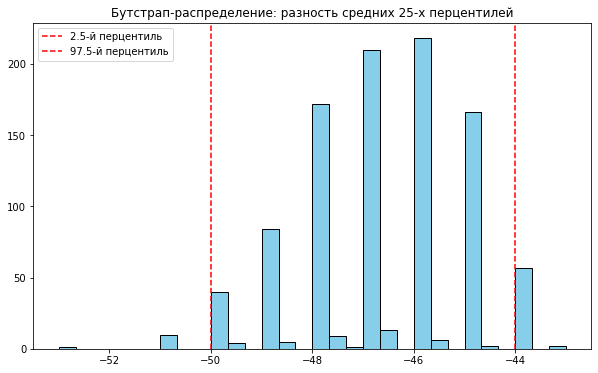

50-й перцентиль контрольной группы: 118.00
50-й перцентиль тестовой группы: 94.00
95%-й доверительный интервал разности 50-х перцентилей [-27.00, -19.00]



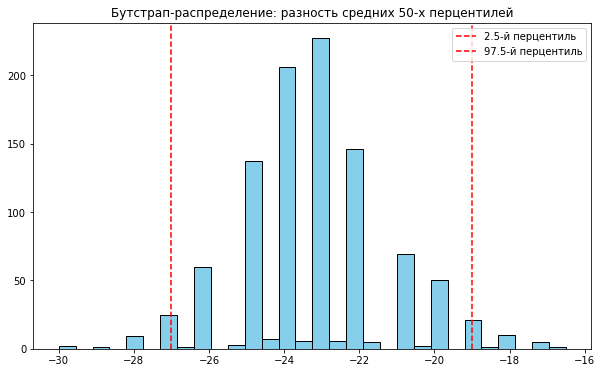

75-й перцентиль контрольной группы: 159.00
75-й перцентиль тестовой группы: 179.50
95%-й доверительный интервал разности 75-х перцентилей [11.49, 30.00]



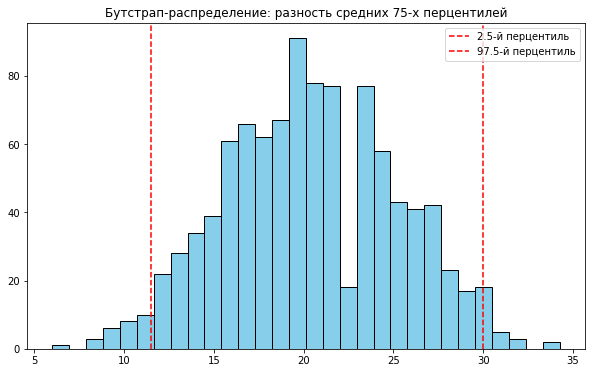

In [116]:
# Запускаем бутстрап и выводим график
for j in [25, 50, 75]:
    n_iterations = 1000
    boot_diffs = []
    for i in range(n_iterations):
        boot_control = np.random.choice(control, size=len(control), replace=True)
        boot_test = np.random.choice(test, size=len(test), replace=True)

        # Для расчёта перцентиля используем .percentile() из библиотеки numpy 
        control_p = np.percentile(boot_control, j)
        test_p = np.percentile(boot_test, j)

        # Находим разницу между значениями тестовой и контрольной групп
        boot_diffs.append(test_p - control_p)
    
    # Создаём массив разниц между перцентилями тестовой и контрольной групп
    boot_diffs = np.array(boot_diffs)

    # Доверительный интервал разницы между 95-ми перцентилями (перцентильный метод)
    diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

    # Вывод доверительного интервала
    print(f"{j}-й перцентиль контрольной группы: {np.percentile(control, j):.2f}")
    print(f"{j}-й перцентиль тестовой группы: {np.percentile(test, j):.2f}")
    print(f"95%-й доверительный интервал разности {j}-х перцентилей [{diff_ci[0]:.2f}, {diff_ci[1]:.2f}]\n")  
    
    # Визуализация
    plt.figure(figsize=(10, 6))
    plt.hist(boot_diffs, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(diff_ci[0], color='red', linestyle='--', label='2.5-й перцентиль')
    plt.axvline(diff_ci[1], color='red', linestyle='--', label='97.5-й перцентиль')
    plt.title(f"Бутстрап-распределение: разность средних {j}-х перцентилей")
    plt.legend()
    plt.show()

Выводы: 

**25-й перцентиль**: в контрольной группе он составляет 95, а в тестовой — 48. Разница составила на 47 единиц в тестовой группе по сравнению с контрольной. Доверительный интервал разности [-50, -44] показывает, что разница между группами статистически значима и отрицательна. Это означает, что пользователи, которые раньше вносили небольшие суммы, действительно стали вносить меньше средств или перестали платить. Гипотеза подтверждается.

**50-й перцентиль (медиана)**: в контрольной группе — 118, в тестовой — 94. Доверительный интервал разности [-27, -19] также указывает на статистически значимое снижение в тестовой группе. Это может означать, что не только пользователи с небольшими вложениями изменили своё поведение, но и те, кто находился в середине распределения.

**75-й перцентиль**: в контрольной группе — 159, в тестовой — 179.5. Доверительный интервал разности [11, 30] показывает статистически значимый рост в тестовой группе (на 20 единиц). Это подтверждает гипотезу о том, что пользователи, склонные к более крупным инвестициям, стали вносить больше средств.


**Таким образом, новая фича повлияла на поведение пользователей: те, кто вносил небольшие суммы, стали вкладывать меньше, а те, кто делал крупные инвестиции, — больше**.

---

### 5. Выводы

**Общий вывод**: проведённое исследование показало, что обновлённый онбординг с подробной информацией о финансовых активах и связанных с ними рисках не оказал негативного эффекта, в некоторых случаях он позитивно повлиял на поведение пользователей. Несмотря на опасения, что углублённый онбординг может отпугнуть клиентов, результаты эксперимента подтвердили гипотезу, что обучающий онбординг помогает пользователям лучше понимать принципы инвестирования.

**Влияние новой фичи на продукт**:

- Подтверждение гипотезы роста:
обновлённый онбординг помог пользователям лучше понимать принципы инвестирования, что привело к увеличению конверсии из первого депозита во второй.


- Опровержение гипотезы риска:
информация о возможных потерях и высоких рисках не отпугнула пользователей от внесения первого депозита.


- Дополнительная гипотеза:
пользователи, которые выбрали высокорискованные активы, стали чаще возвращаться и открывать второй депозит, что подтверждает, что обновлённый онбординг помогает пользователям принимать более осознанные решения.

**Основные результаты и инсайты**

- Динамика привлечения пользователей на историческом периоде показывает положительные результаты, но при этом наблюдается несколько резких подъемов и спадов, которые невелируют друг друга. Самые низкие показатели оказались у Аргентины. Бразилия и Мексика демонстрируют высокий прирост новых пользоваталей, однако для последней страны наблюдается тенденция к снижению.

- Ключевая метрика (**средняя сумма всех депозитов на одного пользователя**): новая фича не оказала значительного влияния на общую сумму депозитов на одного пользователя.

- Барьерная метрика (**конверсия из регистрации в первый депозит**): конверсия из регистрации в первый депозит одинакова в обеих группах. Это подтверждает, что новый онбординг не отпугнул пользователей от внесения первого депозита.

- Вспомогательная метрика 1 (**конверсия из первого депозита во второй**): конверсия из первого депозита во второй в тестовой группе показала рост по сравнению с контрольной. Это подтверждает гипотезу роста, что пользователи, прошедшие обновлённый онбординг, чаще открывают второй депозит.

- Вспомогательная метрика 2 (**средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит**): средняя сумма на одного платящего клиента в тестовой группе выше, чем в контрольной группе. Это указывает на то, что пользователи, прошедшие обновлённый онбординг, в среднем вносят больше средств.

- Влияние уровня риска актива на открытие второго депозита: **во всех группах риска в тестовой группе вероятность открытия второго депозита выше, чем в контрольной. Особенно значимое различие наблюдается для групп с низким и высоким уровнем риска**.


**Поведение пользователей с разным уровнем депозитов**:
- пользователи, которые раньше вносили небольшие суммы, стали вносить меньше средств или перестали платить.
- пользователи со средними вложениями также снизили свои вложения.
- пользователи, склонные к более крупным инвестициям, стали вносить больше средств.

**Рекомендации для бизнеса**:

- **Продолжать улучшать онбординг**: продолжить использование обновлённого онбординга, так как он способствует лучшему пониманию принципов инвестирования и увеличивает конверсию во второй депозит.

- **Ввести дополнительное обучение и поддержку**: предоставлять пользователям дополнительные образовательные материалы и поддержку, чтобы помочь им принимать более осознанные инвестиционные решения.

- **Произвести сегментацию пользователей**: разработать более персонализированный подход к онбордингу по странам, учитывая уровень риска, который выбирают пользователи. Это может помочь улучшить вовлечённость и увеличить средний размер депозитов.


**Риски для бизнеса**:

- Потеря пользователей с небольшими вложениями: необходимо следить за поведением пользователей с небольшими вложениями, чтобы минимизировать их отток.

- Изменение поведения пользователей: важно продолжать анализировать поведение пользователей (особенно по странам, проверить не ухудшила ли новая фича пользовательский опыт у Мексики, так как к концу исторического периода показатели прироста у данной страны снижаются).